# 🧠 Stroke Prediction — EDA & Data Processing

## Etapas principales:
- Análisis exploratorio de datos (EDA)
- Tratamiento de valores faltantes
- Codificación
- Construcción del dataset final
- Definición del modelo baseline

Se prioriza evitar fuga de información y mantener coherencia estadística en el preprocesamiento.


## 1. Carga e inspección inicial del dataset

> En esta primera etapa se carga el conjunto de datos original y se realiza una inspección preliminar de su estructura, tipos de variables y calidad general.

El objetivo de esta revisión inicial es:

- verificar la forma y composición del dataset,
- identificar variables potencialmente no informativas para el modelado,
- detectar valores faltantes,
- y analizar la distribución de la variable objetivo antes de avanzar con la partición de los datos.

Estas comprobaciones permiten documentar de manera explícita las decisiones de preprocesamiento adoptadas desde el inicio del flujo.


In [142]:
# Importación de librerías y configuración visual
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pathlib import Path
from sklearn.model_selection import train_test_split

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import (
    fbeta_score,
    recall_score,
    precision_score,
    roc_auc_score,
    average_precision_score
)

In [143]:
# ===============================
# CONFIGURACIÓN VISUAL
# ===============================
pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = False
sns.set_style("whitegrid")
sns.set_palette("Set2")

# ===============================
# CARGA DEL DATASET
# ===============================
data_path = Path("../datasets/healthcare-dataset-stroke-data.csv")
df = pd.read_csv(data_path)

print(f"Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()

Dimensiones del dataset: 5110 filas × 12 columnas


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [144]:
# ===============================
# INSPECCIÓN GENERAL DEL DATASET
# ===============================
display(df.info())
display(df.describe(include="all").T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,5110.0,NaN,NaN,NaN,36517.829354,21161.721625,67.0,17741.25,36932.0,54682.0,72940.0
gender,5110,3,Female,2994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5110.0,NaN,NaN,NaN,43.226614,22.612647,0.08,25.0,45.0,61.0,82.0
hypertension,5110.0,NaN,NaN,NaN,0.097456,0.296607,0.0,0.0,0.0,0.0,1.0
heart_disease,5110.0,NaN,NaN,NaN,0.054012,0.226063,0.0,0.0,0.0,0.0,1.0
ever_married,5110,2,Yes,3353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_type,5110,5,Private,2925,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Residence_type,5110,2,Urban,2596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_glucose_level,5110.0,NaN,NaN,NaN,106.147677,45.28356,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,NaN,NaN,NaN,28.893237,7.854067,10.3,23.5,28.1,33.1,97.6


### Eliminación de la columna `id`

La variable `id` se elimina del conjunto de datos porque actúa únicamente como identificador único de cada registro y no contiene información clínica ni demográfica relevante para la predicción.

Desde el punto de vista del modelado, este tipo de variable no aporta capacidad explicativa y puede incluso introducir ruido o patrones espurios si se conserva como predictor. Por este motivo, se excluye antes de continuar con el análisis.

In [145]:
# ===============================
# ELIMINACIÓN DE VARIABLE IDENTIFICADORA
# ===============================
df = df.drop(columns=["id"])
print("Columna 'id' eliminada correctamente.")
print(f"Nuevas dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")

Columna 'id' eliminada correctamente.
Nuevas dimensiones del dataset: 5110 filas × 11 columnas


### Distribución de la variable objetivo

Antes de realizar cualquier partición del dataset, se analiza la distribución de la variable objetivo `stroke`. Esta revisión es importante porque permite detectar posibles problemas de desbalance de clases, un aspecto especialmente relevante en tareas de clasificación médica.

Conocer esta distribución desde el inicio ayuda a justificar decisiones posteriores, como el uso de partición estratificada y la elección de métricas adecuadas para la evaluación del desempeño.

In [146]:
# ===============================
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ===============================
target_counts = df["stroke"].value_counts().sort_index()
target_props = df["stroke"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_props.round(2)
})

display(target_summary)

,count,percentage
stroke,,
0,4861,95.13
1,249,4.87


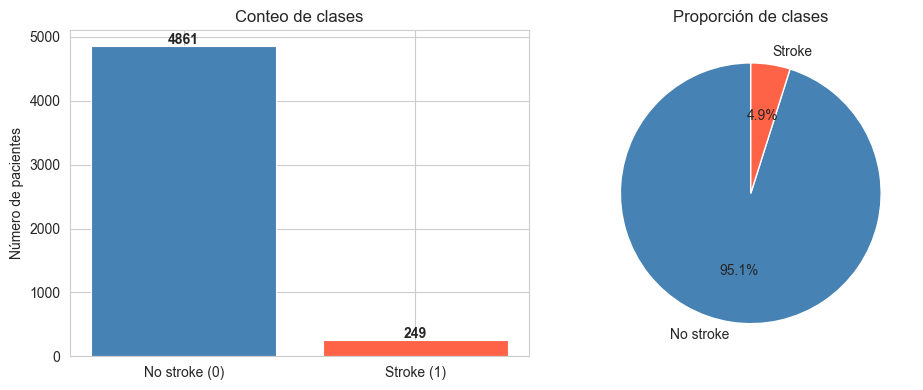

In [147]:
# ===============================
# VISUALIZACIÓN DEL DESBALANCE DE CLASES
# ===============================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Conteo absoluto
axes[0].bar(
    ["No stroke (0)", "Stroke (1)"],
    target_counts.values,
    color=["steelblue", "tomato"],
    edgecolor="white",
    linewidth=0.8
)
axes[0].set_title("Conteo de clases")
axes[0].set_ylabel("Número de pacientes")

for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

# Proporción
axes[1].pie(
    target_counts.values,
    labels=["No stroke", "Stroke"],
    autopct="%1.1f%%",
    colors=["steelblue", "tomato"],
    startangle=90,
    wedgeprops={"edgecolor": "white"}
)
axes[1].set_title("Proporción de clases")

plt.tight_layout()
plt.show()

Comentario: Se observa un fuerte desbalance entre las clases

### División del dataset

Antes de avanzar con el análisis detallado y el preprocesamiento, se divide el dataset en conjuntos de entrenamiento, validación y testeo.

Esta partición se realiza en una etapa temprana del pipeline para evitar **data leakage**.

Se utiliza partición estratificada en función de la variable objetivo `stroke`, con el fin de preservar la proporción de clases en cada subconjunto, lo cual es especialmente importante dado el desbalance presente en el dataset.


In [148]:
# ---
# Split de datos en entrenamiento y validación
# Se utiliza stratify para mantener la proporción de casos de stroke en ambos sets
X = df.drop(columns="stroke")
y = df["stroke"].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Shapes:")
print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")


Shapes:
Train: (3066, 10)
Validation: (1022, 10)
Test: (1022, 10)


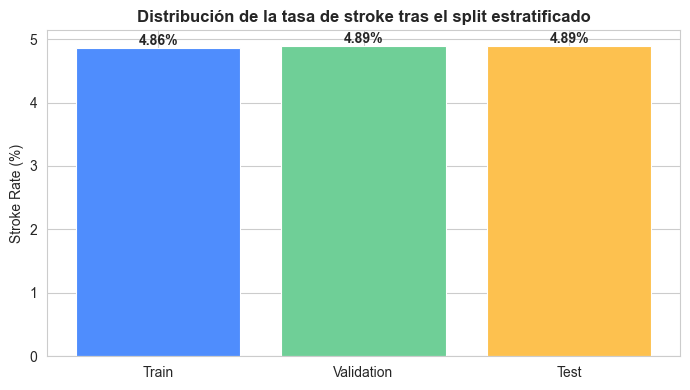


🔎 RESUMEN DEL SPLIT
Train size: 3066
Validation size: 1022
Test size: 1022

Stroke rate (train): 4.86%
Stroke rate (validation): 4.89%
Stroke rate (test): 4.89%

Conclusión:
- El split estratificado preserva la distribución de clases en todos los subconjuntos.


In [149]:
# ===============================
# VISUALIZACIÓN DE LA DISTRIBUCIÓN DEL TARGET TRAS EL SPLIT
# ===============================

plt.figure(figsize=(7, 4))

# Tasas de stroke (%)
split_rates = [
    y_train.mean() * 100,
    y_val.mean() * 100,
    y_test.mean() * 100
]

labels = ["Train", "Validation", "Test"]

bars = plt.bar(
    labels,
    split_rates,
    color=["#4F8DFD", "#6FCF97", "#FDC14F"],
    edgecolor="white",
    linewidth=0.8
)

plt.title("Distribución de la tasa de stroke tras el split estratificado",
          fontsize=12, fontweight="bold")
plt.ylabel("Stroke Rate (%)")

# Etiquetas sobre las barras
for bar, val in zip(bars, split_rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ===============================
# RESUMEN NUMÉRICO
# ===============================

print("\n" + "=" * 60)
print("🔎 RESUMEN DEL SPLIT")
print("=" * 60)

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}\n")

print(f"Stroke rate (train): {y_train.mean()*100:.2f}%")
print(f"Stroke rate (validation): {y_val.mean()*100:.2f}%")
print(f"Stroke rate (test): {y_test.mean()*100:.2f}%")

print("\nConclusión:")
print("- El split estratificado preserva la distribución de clases en todos los subconjuntos.")

### Definición del dataset de entrenamiento para análisis

A partir de la partición realizada, se reconstruye un único DataFrame correspondiente al conjunto de entrenamiento, incluyendo tanto las variables predictoras como la variable objetivo.

Este dataset se utilizará para realizar todos los análisis exploratorios y definir las transformaciones de preprocesamiento (tratamiento de valores faltantes, encoding, etc.).

Es importante destacar que estas decisiones se basan exclusivamente en el conjunto de entrenamiento, con el objetivo de evitar data leakage y garantizar una evaluación válida del modelo.

In [150]:
# ===============================
# DATASET DE ENTRENAMIENTO PARA ANÁLISIS
# ===============================

# Se reconstruye el dataset de entrenamiento incluyendo la variable objetivo
df_train = pd.concat([X_train, y_train], axis=1)
print(f"Dimensiones del dataset de entrenamiento: {df_train.shape}")
df_train.head()

Dimensiones del dataset de entrenamiento: (3066, 11)


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3135,Male,44.0,1,0,Yes,Private,Rural,84.10,NaN,Unknown,0
3455,Male,75.0,0,0,Yes,Govt_job,Urban,223.14,27.8,never smoked,0
1438,Male,47.0,0,0,Yes,Private,Rural,93.55,31.4,never smoked,0
1566,Male,76.0,0,1,Yes,Self-employed,Rural,101.43,29.1,Unknown,0
4182,Female,28.0,0,0,No,Private,Rural,104.16,21.5,never smoked,0


## 2. Análisis exploratorio de datos (EDA)

En esta sección se realiza un análisis exploratorio del conjunto de entrenamiento con el objetivo de comprender la distribución de las variables, detectar posibles patrones y evaluar su relación con la variable objetivo.

Este análisis permite fundamentar las decisiones de preprocesamiento y selección de variables en etapas posteriores del pipeline.

In [151]:
# ===============================
# FEATURE TYPING
# ===============================

# Variables numéricas (continuas)
num_cols = [
    "age",
    "avg_glucose_level",
    "bmi"
]

# Variables categóricas (incluye binarias)
cat_cols = [
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status",
    "hypertension",      # binaria → categórica
    "heart_disease"      # binaria → categórica
]

print("Numerical variables:", num_cols)
print("Categorical variables:", cat_cols)

Numerical variables: ['age', 'avg_glucose_level', 'bmi']
Categorical variables: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'hypertension', 'heart_disease']


### 2.1 Análisis de variables numéricas


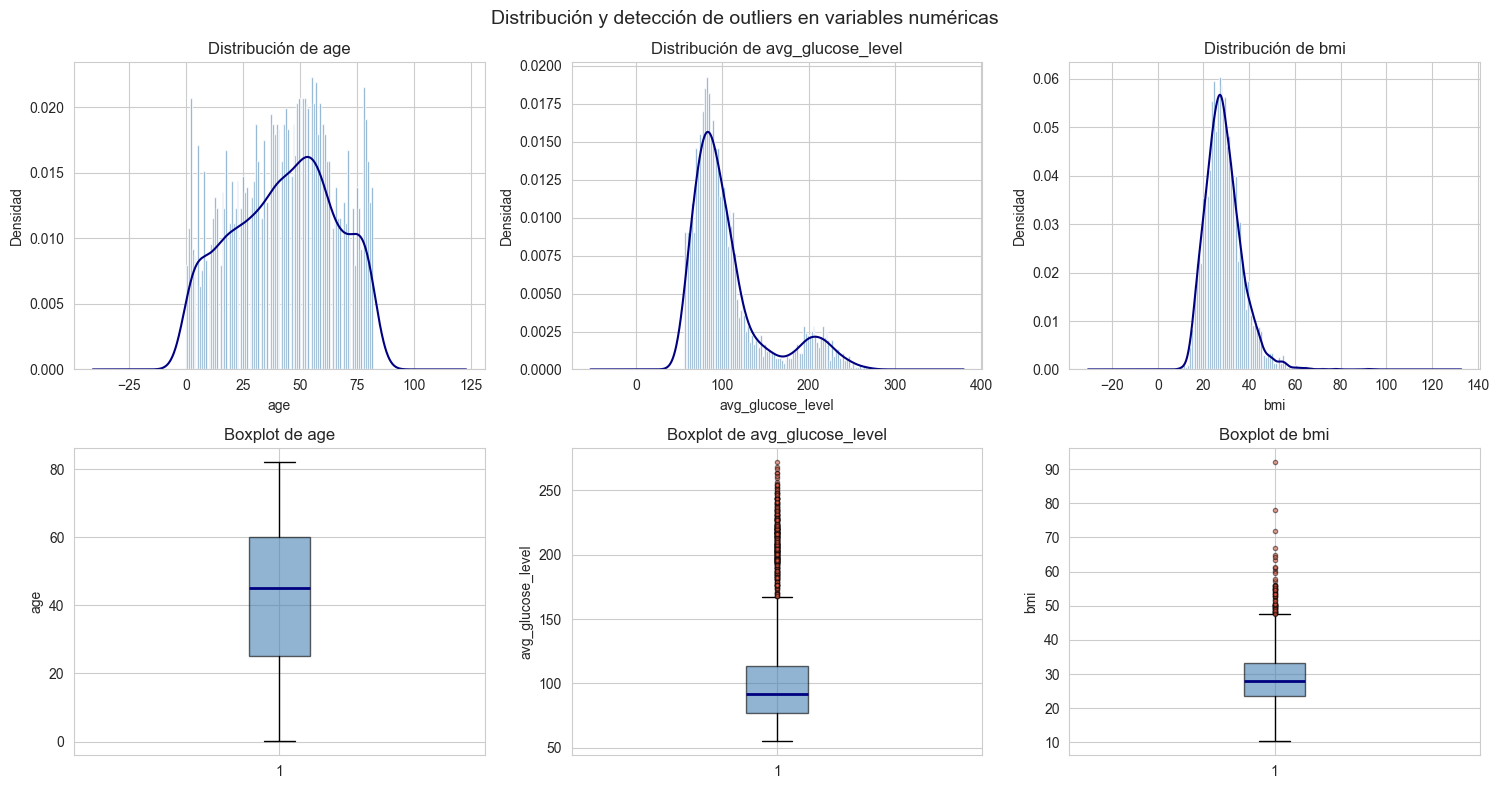

In [152]:
# ===============================
# DISTRIBUCIÓN Y OUTLIERS — VARIABLES NUMÉRICAS
# ===============================

fig, axes = plt.subplots(2, len(num_cols), figsize=(5 * len(num_cols), 8))

for i, col in enumerate(num_cols):
    # Histograma + KDE
    axes[0, i].hist(
        df_train[col].dropna(),
        bins=100,
        color="steelblue",
        edgecolor="white",
        alpha=0.8,
        density=True
    )
    
    df_train[col].dropna().plot(
        kind="kde",
        ax=axes[0, i],
        color="navy",
        linewidth=1.5
    )
    
    axes[0, i].set_title(f"Distribución de {col}")
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel("Densidad")

    # Boxplot
    axes[1, i].boxplot(
        df_train[col].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor="steelblue", alpha=0.6),
        medianprops=dict(color="navy", linewidth=2),
        flierprops=dict(
            marker="o",
            markersize=3,
            markerfacecolor="tomato",
            alpha=0.5
        )
    )
    
    axes[1, i].set_title(f"Boxplot de {col}")
    axes[1, i].set_ylabel(col)

plt.suptitle("Distribución y detección de outliers en variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()

In [153]:
# ===============================
# ANÁLISIS DE ASIMETRÍA
# ===============================

skew_summary = pd.DataFrame({
    "feature": num_cols,
    "skewness": [df_train[col].skew() for col in num_cols]
}).sort_values(by="skewness", key=np.abs, ascending=False)

display(skew_summary)

,feature,skewness
1,avg_glucose_level,1.582528
2,bmi,1.050677
0,age,-0.135039


#### Observaciones

A partir del análisis de las distribuciones y de la medida de asimetría, se identifican las siguientes características:

- Las variables `avg_glucose_level` y `bmi` presentan distribuciones con sesgo positivo, evidenciando colas largas hacia valores altos.
- Los valores extremos observados no parecen corresponder a errores de medición, sino a casos clínicamente plausibles.
- En consecuencia, no resulta apropiado tratarlos como outliers a eliminar, sino como parte de la variabilidad natural del fenómeno.

Dado este comportamiento, se considerará la aplicación de transformaciones no lineales (por ejemplo, logarítmicas) en etapas posteriores del procesamiento, con el objetivo de estabilizar la varianza y mejorar la capacidad de modelado.

### 2.2 Relación entre variables numéricas y la variable objetivo

Se analiza la distribución de las variables numéricas en función de la variable objetivo `stroke`, con el objetivo de evaluar su capacidad discriminativa.

Este análisis permite identificar patrones diferenciales entre clases y determinar qué variables podrían aportar mayor información al modelo.

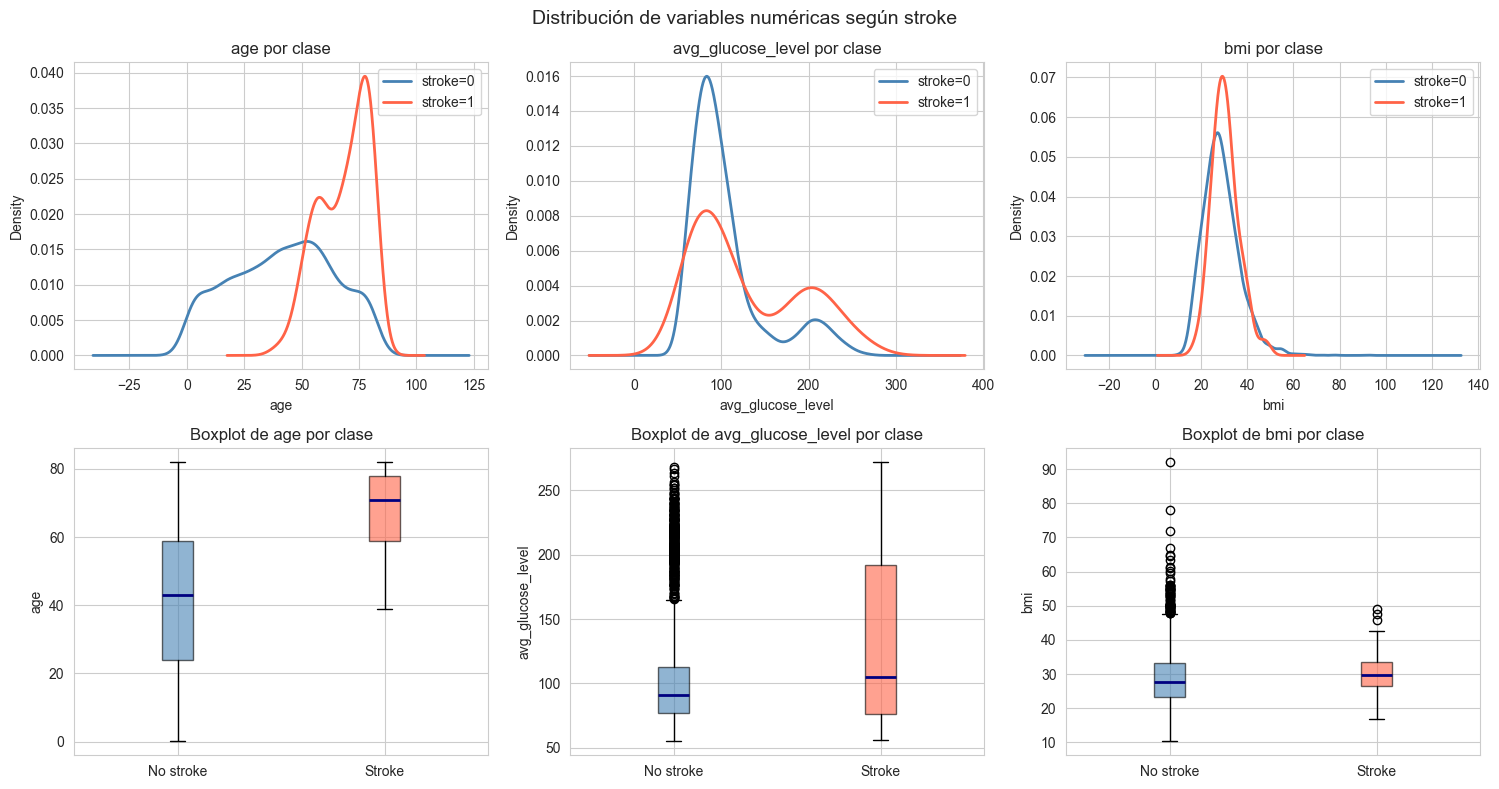

In [154]:
# ===============================
# VARIABLES NUMÉRICAS VS TARGET
# ===============================

fig, axes = plt.subplots(2, len(num_cols), figsize=(5 * len(num_cols), 8))

for i, col in enumerate(num_cols):
    
    # KDE por clase
    for label, color in zip([0, 1], ["steelblue", "tomato"]):
        subset = df_train[df_train["stroke"] == label][col].dropna()
        subset.plot(
            kind="kde",
            ax=axes[0, i],
            label=f"stroke={label}",
            color=color,
            linewidth=2
        )
    
    axes[0, i].set_title(f"{col} por clase")
    axes[0, i].set_xlabel(col)
    axes[0, i].legend()

    # Boxplot por clase
    data_by_class = [
        df_train[df_train["stroke"] == lbl][col].dropna()
        for lbl in [0, 1]
    ]

    bp = axes[1, i].boxplot(
        data_by_class,
        labels=["No stroke", "Stroke"],
        patch_artist=True,
        medianprops=dict(color="navy", linewidth=2)
    )

    bp["boxes"][0].set_facecolor("steelblue")
    bp["boxes"][0].set_alpha(0.6)
    bp["boxes"][1].set_facecolor("tomato")
    bp["boxes"][1].set_alpha(0.6)

    axes[1, i].set_title(f"Boxplot de {col} por clase")
    axes[1, i].set_ylabel(col)

plt.suptitle("Distribución de variables numéricas según stroke", fontsize=14)
plt.tight_layout()
plt.show()

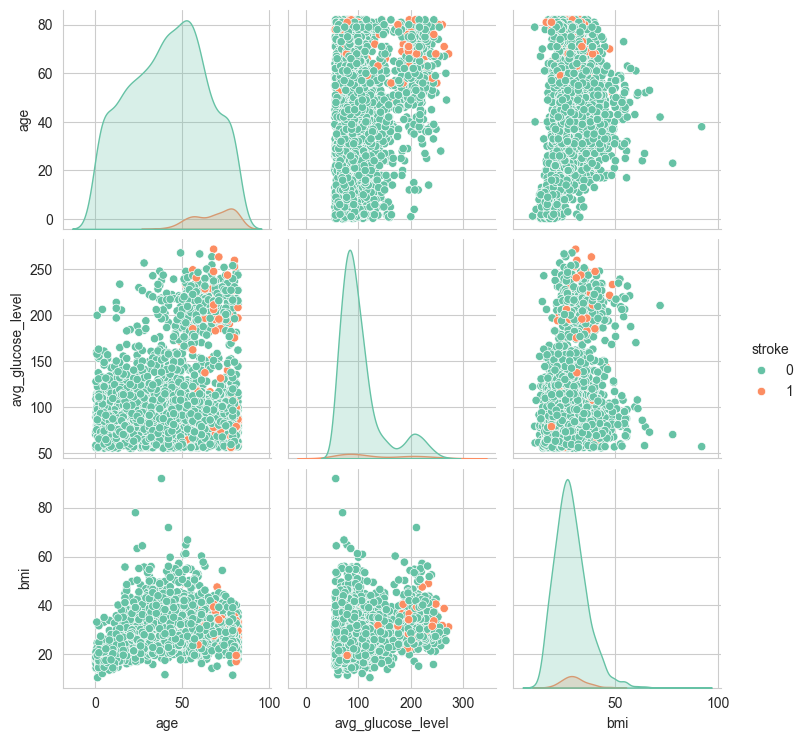

In [155]:
sns.pairplot(
    df_train[["age", "avg_glucose_level", "bmi", "stroke"]].dropna(),
    hue="stroke",
    diag_kind="kde"
)
plt.show()

#### Observaciones

El análisis de las variables numéricas en función de la variable objetivo permite identificar patrones relevantes:

- La variable `age` muestra una clara separación entre clases, con una mayor concentración de casos de stroke en edades más avanzadas.
- La variable `avg_glucose_level` presenta cierta diferenciación, observándose valores más elevados en general en la clase positiva.
- La variable `bmi` muestra menor capacidad discriminativa de forma individual, aunque podría aportar información en combinación con otras variables.

En conjunto, se observa que algunas variables numéricas presentan señales útiles para la predicción, mientras que otras podrían requerir transformaciones o interacción con otras variables para mejorar su aporte al modelo.

### 2.3 Análisis de variables categóricas


C:\Users\pc\AppData\Local\Temp\ipykernel_22128\994954385.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x=col, order=order, ax=axes[i],
C:\Users\pc\AppData\Local\Temp\ipykernel_22128\994954385.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x=col, order=order, ax=axes[i],
C:\Users\pc\AppData\Local\Temp\ipykernel_22128\994954385.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x=col, order=order, ax=axes[i],
C:\Users\pc\AppData\Local\Temp\ipykernel_22128\994954385.py:6: FutureWarn

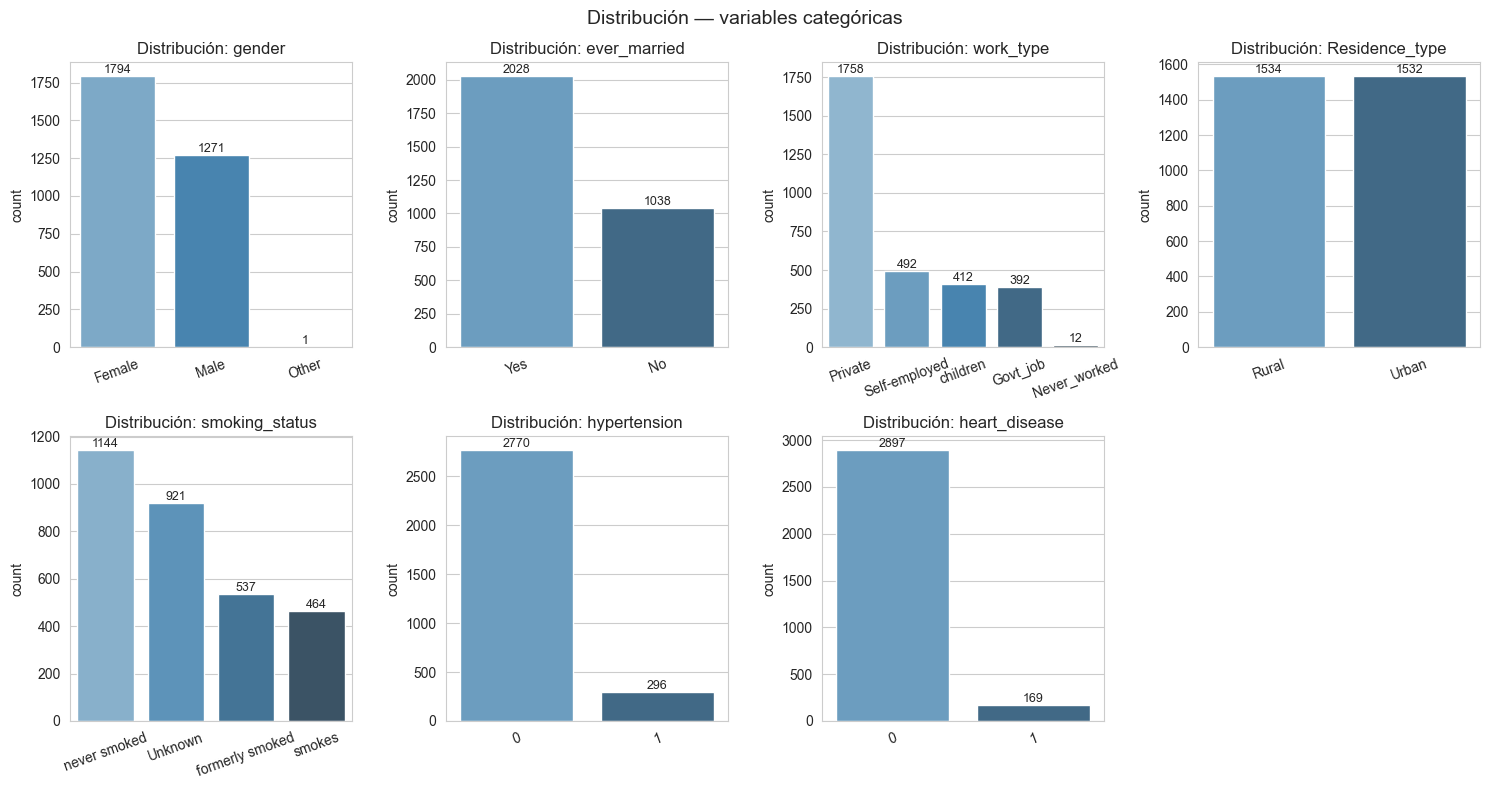

In [156]:

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df_train[col].value_counts().index
    sns.countplot(data=df_train, x=col, order=order, ax=axes[i],
                  palette="Blues_d", edgecolor="white")
    axes[i].set_title(f"Distribución: {col}")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=20)
    # Anotar conteos
    for p in axes[i].patches:
        axes[i].annotate(f"{int(p.get_height())}",
                         (p.get_x() + p.get_width() / 2, p.get_height()),
                         ha="center", va="bottom", fontsize=9)

axes[-1].set_visible(False)  # Ocultar el subplot sobrante
plt.suptitle("Distribución — variables categóricas", fontsize=14)
plt.tight_layout()
plt.show()

#### Observaciones


- Algunas variables presentan categorías dominantes, lo que podría influir en el aprendizaje del modelo.
- Se observa la presencia de la categoría "Unknown" en `smoking_status`, que será analizada en detalle en etapas posteriores.
- Se observa que `gender` tiene un único valor en la categoría `other`
- Se observan posibles agrupamientos para la feature `work_type`. Por ejemplo, children y Never_worked 

### 2.4 Relación entre variables categóricas y la variable objetivo

A continuación se analiza la distribución de la variable objetivo `stroke` dentro de cada categoría.


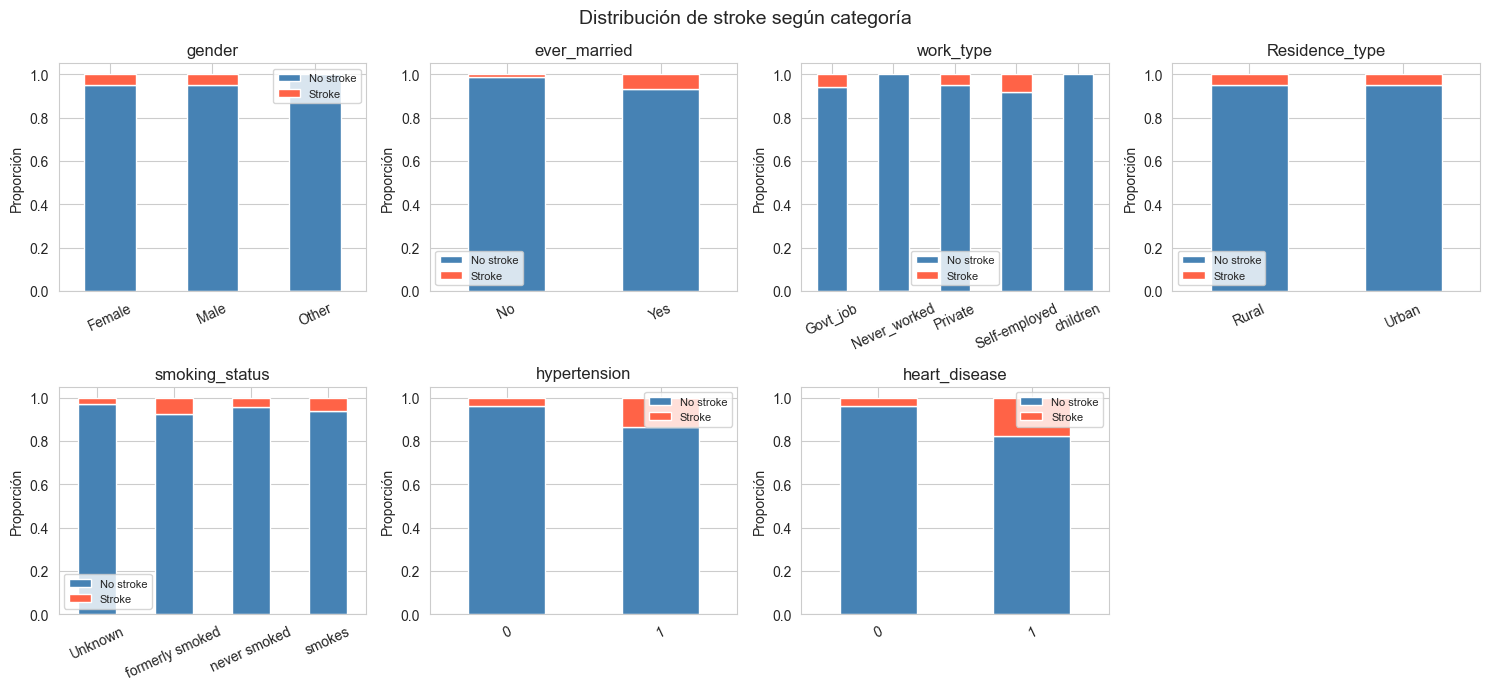

In [157]:
# ===============================
# VARIABLES CATEGÓRICAS VS TARGET
# ===============================

n_cols = 4
n_rows = int(np.ceil(len(cat_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    
    cross = pd.crosstab(
        df_train[col],
        df_train["stroke"],
        normalize="index"
    )

    cross = cross[[0, 1]] if 0 in cross.columns and 1 in cross.columns else cross

    cross.plot(
        kind="bar",
        stacked=True,
        ax=axes[i],
        color=["steelblue", "tomato"],
        edgecolor="white"
    )
    
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Proporción")
    axes[i].tick_params(axis="x", rotation=25)
    axes[i].legend(["No stroke", "Stroke"], fontsize=8)

# Ocultar subplots sobrantes
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribución de stroke según categoría", fontsize=14)
plt.tight_layout()
plt.show()

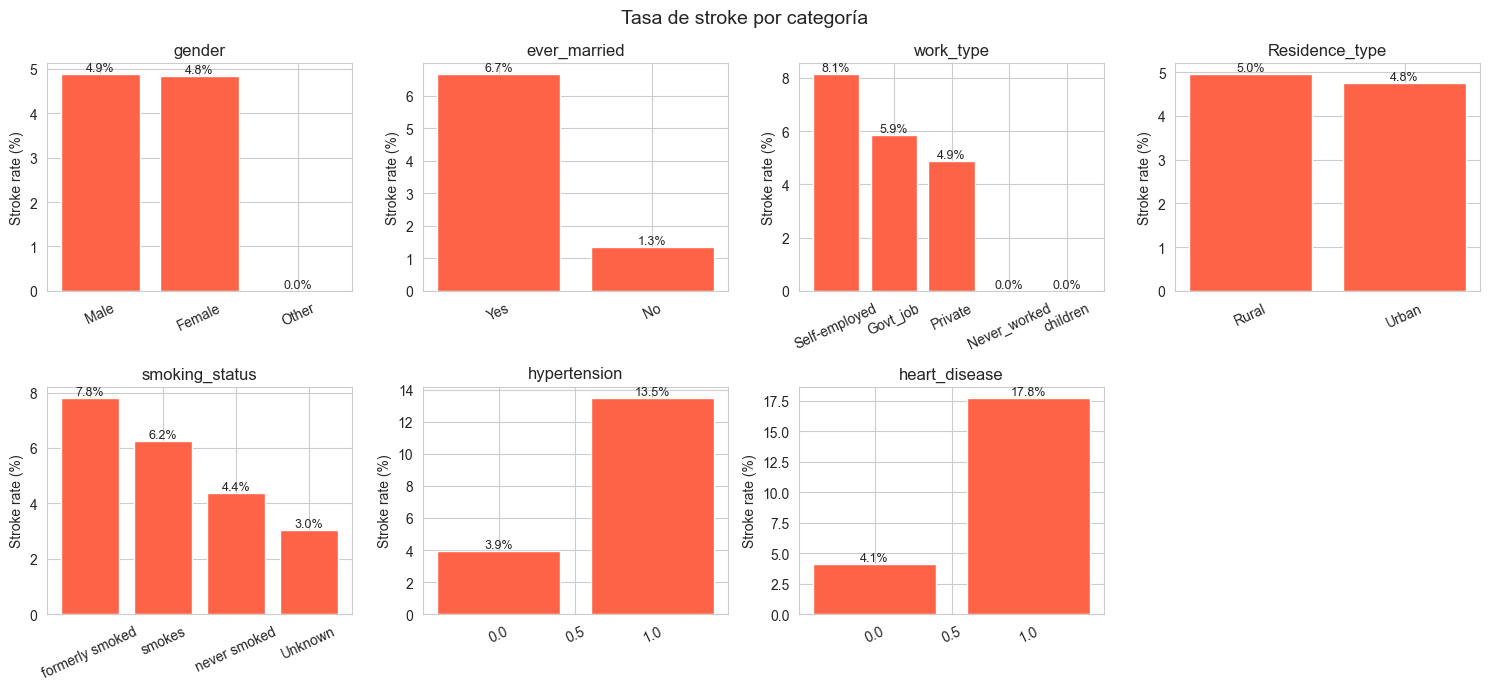

In [158]:
# ===============================
# TASA DE STROKE POR CATEGORÍA
# ===============================

n_cols = 4
n_rows = int(np.ceil(len(cat_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    
    stroke_rate = df_train.groupby(col)["stroke"].mean().sort_values(ascending=False) * 100
    
    bars = axes[i].bar(
        stroke_rate.index,
        stroke_rate.values,
        color="tomato",
        edgecolor="white"
    )
    
    axes[i].set_title(col)
    axes[i].set_ylabel("Stroke rate (%)")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=25)

    # Anotar valores
    for bar, val in zip(bars, stroke_rate.values):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

# Ocultar sobrantes
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Tasa de stroke por categoría", fontsize=14)
plt.tight_layout()
plt.show()

#### Observaciones

- Las variables `hypertension` y `heart_disease` muestran una mayor proporción de casos de stroke en presencia de la condición.
- La feature `ever_married` presenta una mayor proporción de casos de stroke en el caso positivo. 
- Algunas variables presentan diferencias moderadas entre categorías, lo que sugiere una posible contribución al modelo.
- La variable `smoking_status` no muestra una separación tan marcada entre categorías, por lo que requerirá análisis complementario antes de definir su tratamiento.
- `work_type` con el valor de `self_employed` presenta una tasa de stroke un poco mas alta que las demás categorías.

### 2.4 Análisis de correlaciones y asociaciones

Se analiza la relación entre las variables y la variable objetivo mediante distintas métricas, con el objetivo de cuantificar su grado de asociación.

Se utilizan:

- **correlación de Pearson** para evaluar relaciones lineales entre variables numéricas,
- **correlación de Spearman** para capturar relaciones monotónicas no necesariamente lineales,
- **información mutua** para capturar dependencias no lineales entre variables y la variable objetivo.
- **correlación point-biserial** para medir la asociación entre variables numéricas y la variable objetivo binaria,
- **coeficiente de Cramér's V** para cuantificar la relación entre variables categóricas,
- **test de chi-cuadrado** como medida de significancia estadística en variables categóricas,


Este análisis permite complementar la interpretación visual realizada previamente y obtener una medida cuantitativa del aporte potencial de cada variable al modelo.

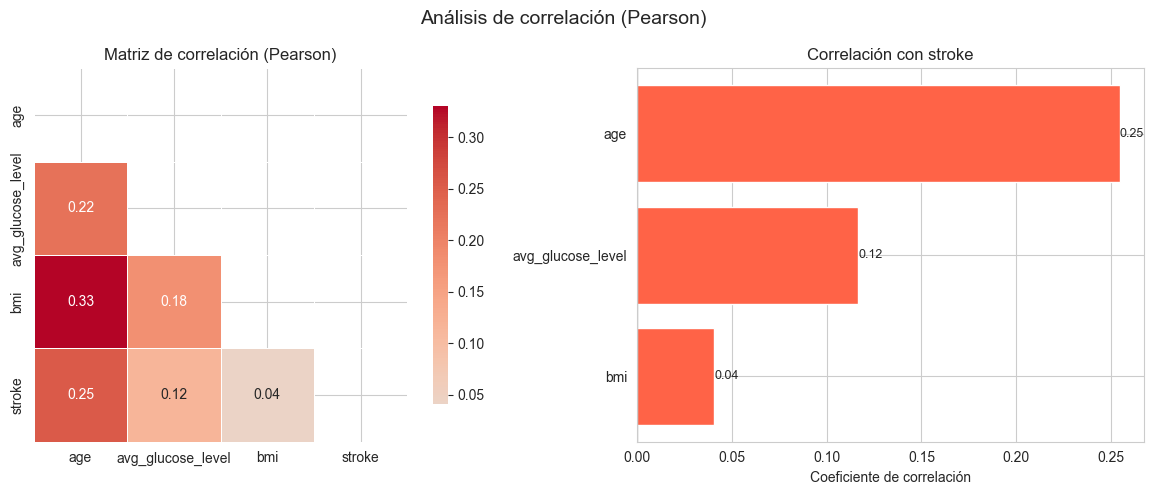

In [159]:
# ===============================
# MATRIZ DE CORRELACIÓN PEARSON + TARGET
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

corr_df = df_train[num_cols + ["stroke"]].copy()
corr = corr_df.corr(method="pearson")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------- HEATMAP --------
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=axes[0]
)

axes[0].set_title("Matriz de correlación (Pearson)")

# -------- CORRELACIÓN CON TARGET --------
target_corr = corr["stroke"].drop("stroke").sort_values()

colors = ["tomato" if v > 0 else "steelblue" for v in target_corr]

bars = axes[1].barh(
    target_corr.index,
    target_corr.values,
    color=colors,
    edgecolor="white"
)

axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlación con stroke")
axes[1].set_xlabel("Coeficiente de correlación")

# etiquetas
for bar, val in zip(bars, target_corr.values):
    axes[1].text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}",
        va="center",
        fontsize=9
    )

plt.suptitle("Análisis de correlación (Pearson)", fontsize=14)
plt.tight_layout()
plt.show()

#### Observaciones

La matriz de correlación basada en el coeficiente de Pearson permite analizar relaciones lineales entre variables:

- La variable `age` presenta la mayor correlación positiva con la variable objetivo.


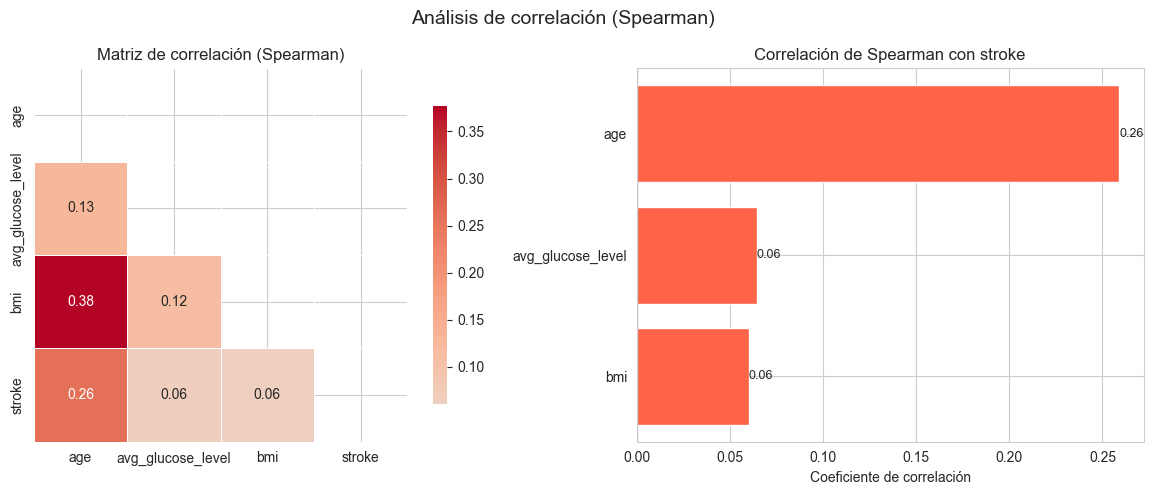

In [160]:
# ===============================
# MATRIZ DE CORRELACIÓN DE SPEARMAN
# ===============================

corr_df = df_train[num_cols + ["stroke"]].copy()
corr_spearman = corr_df.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Heatmap
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

sns.heatmap(
    corr_spearman,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=axes[0]
)

axes[0].set_title("Matriz de correlación (Spearman)")

# Correlación con target
target_corr_spearman = corr_spearman["stroke"].drop("stroke").sort_values()

colors = ["tomato" if v > 0 else "steelblue" for v in target_corr_spearman]

bars = axes[1].barh(
    target_corr_spearman.index,
    target_corr_spearman.values,
    color=colors,
    edgecolor="white"
)

axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlación de Spearman con stroke")
axes[1].set_xlabel("Coeficiente de correlación")

for bar, val in zip(bars, target_corr_spearman.values):
    axes[1].text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}",
        va="center",
        fontsize=9
    )

plt.suptitle("Análisis de correlación (Spearman)", fontsize=14)
plt.tight_layout()
plt.show()

#### Observaciones

La correlación de Spearman complementa el análisis de Pearson al capturar relaciones monotónicas que no necesariamente son lineales. Concluyen que age es la feature más correlacionada con stroke


,feature,mutual_info
0,age,0.041557
2,bmi,0.008575
1,avg_glucose_level,0.006615


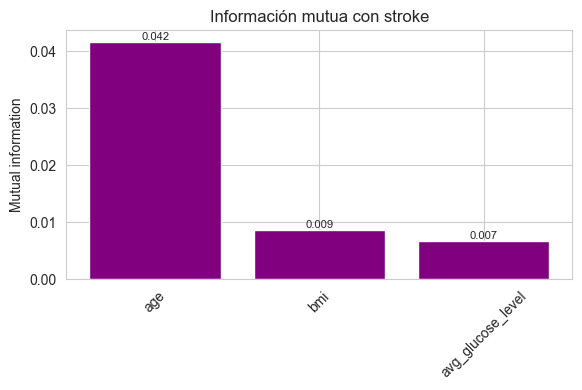

In [161]:
from sklearn.feature_selection import mutual_info_classif

X_num = df_train[num_cols].copy()
y_num = df_train["stroke"].copy()

# Para mutual information no puede haber NaN
X_num_mi = X_num.copy()
for col in X_num_mi.columns:
    X_num_mi[col] = X_num_mi[col].fillna(X_num_mi[col].median())

mi = mutual_info_classif(X_num_mi, y_num, random_state=42)

mi_df = pd.DataFrame({
    "feature": X_num.columns,
    "mutual_info": mi
}).sort_values(by="mutual_info", ascending=False)

display(mi_df)
plt.figure(figsize=(6, 4))
bars = plt.bar(mi_df["feature"], mi_df["mutual_info"], color="purple", edgecolor="white")
plt.title("Información mutua con stroke")
plt.ylabel("Mutual information")
plt.xticks(rotation=45)

for bar, val in zip(bars, mi_df["mutual_info"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{val:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

,feature,correlation,abs_correlation,p_value
0,age,0.254381,0.254381,1.742723e-46
1,avg_glucose_level,0.116566,0.116566,9.553223e-11
2,bmi,0.040787,0.040787,2.702573e-02


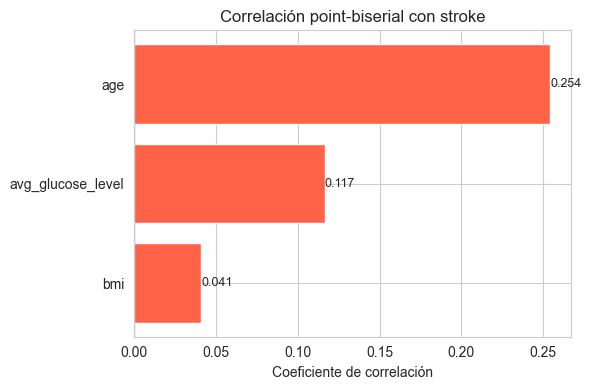

In [162]:
# ===============================
# CORRELACIÓN POINT-BISERIAL
# ===============================

from scipy.stats import pointbiserialr

results_pb = []

for col in num_cols:
    # Eliminar NaN para el cálculo
    valid_data = df_train[[col, "stroke"]].dropna()
    
    r, p = pointbiserialr(valid_data["stroke"], valid_data[col])
    
    results_pb.append({
        "feature": col,
        "correlation": r,
        "abs_correlation": abs(r),
        "p_value": p
    })

pb_df = pd.DataFrame(results_pb).sort_values(
    by="abs_correlation",
    ascending=False
).reset_index(drop=True)

display(pb_df)
# ===============================
# VISUALIZACIÓN POINT-BISERIAL
# ===============================

plt.figure(figsize=(6, 4))

plot_df = pb_df.sort_values(by="correlation")

colors = ["tomato" if v > 0 else "steelblue" for v in plot_df["correlation"]]

bars = plt.barh(
    plot_df["feature"],
    plot_df["correlation"],
    color=colors,
    edgecolor="white"
)

plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlación point-biserial con stroke")
plt.xlabel("Coeficiente de correlación")

for bar, val in zip(bars, plot_df["correlation"]):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

,feature,cramers_v
0,heart_disease,0.141484
1,hypertension,0.128991
2,ever_married,0.115215
3,work_type,0.105156
4,smoking_status,0.079367
5,gender,0.004134
6,Residence_type,0.002886


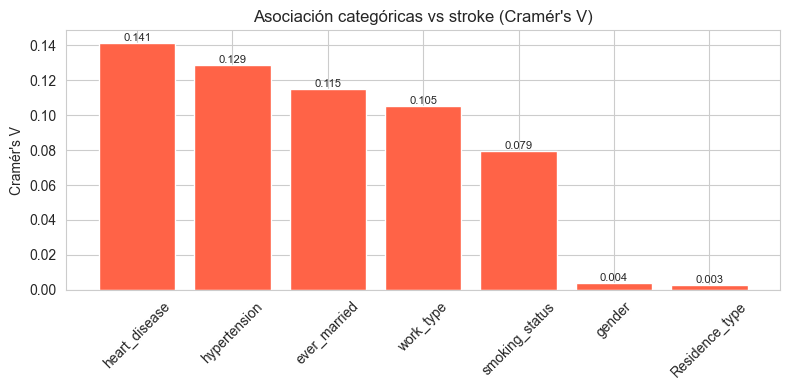

In [163]:
# ===============================
# CRAMÉR'S V PARA CATEGÓRICAS
# ===============================

import scipy.stats as stats

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * min(k - 1, r - 1)))

cramers_results = []

for col in cat_cols:
    cv = cramers_v(df_train[col], df_train["stroke"])
    cramers_results.append({
        "feature": col,
        "cramers_v": cv
    })

cramers_df = pd.DataFrame(cramers_results).sort_values(
    by="cramers_v",
    ascending=False
).reset_index(drop=True)

display(cramers_df)

# ===============================
# VISUALIZACIÓN CRAMÉR'S V
# ===============================

plt.figure(figsize=(8, 4))

bars = plt.bar(
    cramers_df["feature"],
    cramers_df["cramers_v"],
    color="tomato",
    edgecolor="white"
)

plt.title("Asociación categóricas vs stroke (Cramér's V)")
plt.ylabel("Cramér's V")
plt.xticks(rotation=45)

for bar, val in zip(bars, cramers_df["cramers_v"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [164]:
from scipy.stats import chi2_contingency

chi2_results = []

for col in cat_cols:
    contingency_table = pd.crosstab(df_train[col], df_train["stroke"])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    cv = cramers_v(df_train[col], df_train["stroke"])
    
    chi2_results.append({
        "feature": col,
        "chi2_stat": chi2,
        "p_value": p,
        "cramers_v": cv
    })

chi2_df = pd.DataFrame(chi2_results).sort_values(by="cramers_v", ascending=False)
display(chi2_df)

,feature,chi2_stat,p_value,cramers_v
6,heart_disease,61.374539,4.718732e-15,0.141484
5,hypertension,51.014456,9.168820e-13,0.128991
1,ever_married,40.699282,1.775524e-10,0.115215
2,work_type,33.903275,7.800122e-07,0.105156
4,smoking_status,19.312931,2.355426e-04,0.079367
0,gender,0.052408,9.741363e-01,0.004134
3,Residence_type,0.025541,8.730264e-01,0.002886


#### Observaciones

Heart_disease e hypertension son las variables categóricas más correlacionadas


#### Resumen de correlación con stroke


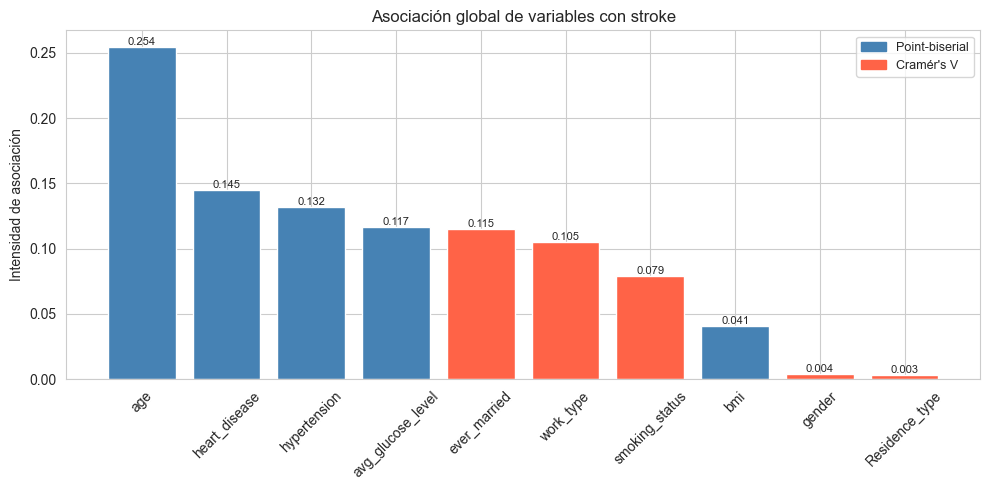

,feature,association_metric,metric_type
0,age,0.254381,Point-biserial
1,heart_disease,0.144807,Point-biserial
2,hypertension,0.131559,Point-biserial
3,avg_glucose_level,0.116566,Point-biserial
4,ever_married,0.115215,Cramér's V
5,work_type,0.105156,Cramér's V
6,smoking_status,0.079367,Cramér's V
7,bmi,0.040787,Point-biserial
8,gender,0.004134,Cramér's V
9,Residence_type,0.002886,Cramér's V


In [165]:
from scipy.stats import pointbiserialr

summary_rows = []

# Numéricas
for col in num_cols:
    valid_data = df_train[[col, "stroke"]].dropna()
    r, _ = pointbiserialr(valid_data["stroke"], valid_data[col])
    summary_rows.append({
        "feature": col,
        "association_metric": abs(r),
        "metric_type": "Point-biserial"
    })

# Binarias categóricas 0/1
for col in ["hypertension", "heart_disease"]:
    r, _ = pointbiserialr(df_train["stroke"], df_train[col])
    summary_rows.append({
        "feature": col,
        "association_metric": abs(r),
        "metric_type": "Point-biserial"
    })

# Categóricas nominales
for col in [c for c in cat_cols if c not in ["hypertension", "heart_disease"]]:
    cv = cramers_v(df_train[col], df_train["stroke"])
    summary_rows.append({
        "feature": col,
        "association_metric": cv,
        "metric_type": "Cramér's V"
    })

global_summary = pd.DataFrame(summary_rows).sort_values(
    by="association_metric",
    ascending=False
).reset_index(drop=True)

plt.figure(figsize=(10, 5))
colors = [
    "steelblue" if m == "Point-biserial" else "tomato"
    for m in global_summary["metric_type"]
]

bars = plt.bar(
    global_summary["feature"],
    global_summary["association_metric"],
    color=colors
)

plt.title("Asociación global de variables con stroke")
plt.ylabel("Intensidad de asociación")
plt.xticks(rotation=45)

for bar, val in zip(bars, global_summary["association_metric"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.legend(handles=[
    plt.Rectangle((0, 0), 1, 1, color="steelblue", label="Point-biserial"),
    plt.Rectangle((0, 0), 1, 1, color="tomato", label="Cramér's V")
], fontsize=9)

plt.tight_layout()
plt.show()

display(global_summary)

#### Conclusión del análisis de correlaciones y asociaciones

El análisis conjunto de las distintas métricas de asociación permite identificar qué variables presentan mayor relevancia individual respecto de la variable objetivo `stroke`.

Los resultados muestran que:

- La variable `age` es la que presenta la mayor asociación con la ocurrencia de stroke, consolidándose como el predictor más relevante del dataset.
- Las variables relacionadas con condiciones médicas (`heart_disease` y `hypertension`) también muestran una asociación significativa, lo cual resulta consistente con el conocimiento del dominio.
- La variable `avg_glucose_level` presenta una asociación moderada, indicando que niveles elevados de glucosa podrían estar vinculados al evento de interés.
- Entre las variables categóricas, `ever_married` y `work_type` muestran cierto nivel de asociación, aunque inferior al de las variables clínicas.
- La variable `smoking_status` presenta una asociación débil, lo que sugiere que su aporte podría ser limitado o depender de interacciones con otras variables.
- La variable `bmi` muestra una asociación muy baja, lo cual coincide con las observaciones previas del análisis exploratorio.
- Variables como `gender` y `Residence_type` no presentan asociación significativa con la variable objetivo.

En conjunto, estos resultados indican que el problema está fuertemente influenciado por variables relacionadas con la edad y condiciones de salud, mientras que otras variables presentan un aporte menor cuando se consideran de manera individual.

## 3. Análisis de valores faltantes

A continuación se revisa la presencia de valores faltantes en el dataset. 

La detección temprana de faltantes permite decidir si conviene eliminar observaciones, imputar valores o conservar temporalmente los nulos para analizarlos con mayor detalle. En este caso, interesa especialmente determinar si la ausencia de datos responde a un patrón sistemático o si puede tratarse de manera razonable mediante imputación.

In [166]:
# ===============================
# REVISIÓN DE VALORES FALTANTES
# ===============================
missing_summary = pd.DataFrame({
    "missing_count": df_train.isnull().sum(),
    "missing_percentage": (df_train.isnull().mean() * 100).round(2)
})

missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values(
    by="missing_count", ascending=False
)

display(missing_summary)

,missing_count,missing_percentage
bmi,127,4.14


Se observa que la única variable con valores faltantes es `bmi`. 

Dado que la proporción de faltantes no es despreciable, no resulta conveniente eliminar directamente esas filas sin antes analizar si la ausencia presenta algún patrón. Por este motivo, se estudia con mayor detalle la relación entre los faltantes de `bmi` y la variable objetivo.

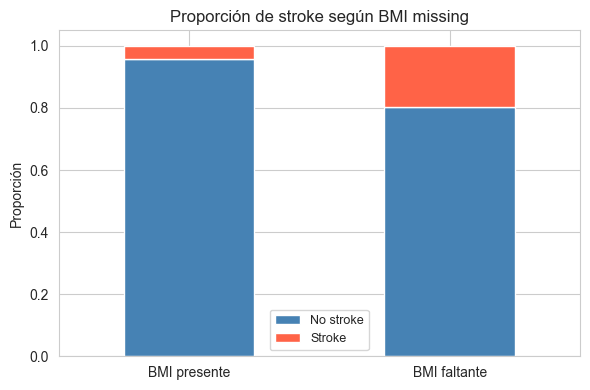

Tasa de stroke por grupo:
  BMI presente: 0.0422
  BMI faltante: 0.1969


In [167]:
# --- ¿Los nulos de BMI están asociados al target? ---

fig, ax = plt.subplots(figsize=(6, 4))

bmi_missing_flag = df_train["bmi"].isnull().astype(int)

# Crosstab normalizado
ctab = pd.crosstab(bmi_missing_flag, y_train, normalize="index")
ctab.index = ["BMI presente", "BMI faltante"]
ctab = ctab.rename(columns={0: "No stroke", 1: "Stroke"})

ctab.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["steelblue", "tomato"],
    edgecolor="white"
)

ax.set_title("Proporción de stroke según BMI missing")
ax.set_ylabel("Proporción")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("Tasa de stroke por grupo:")
print(f"  BMI presente: {y_train[~df_train['bmi'].isnull()].mean():.4f}")
print(f"  BMI faltante: {y_train[df_train['bmi'].isnull()].mean():.4f}")

#### Perfil de los registros con BMI faltante

A continuación se compara el perfil de los pacientes con BMI faltante frente a aquellos con BMI presente.  
Se observan diferencias en variables numéricas y categóricas para evaluar si el faltante sigue algún patrón demográfico o clínico.

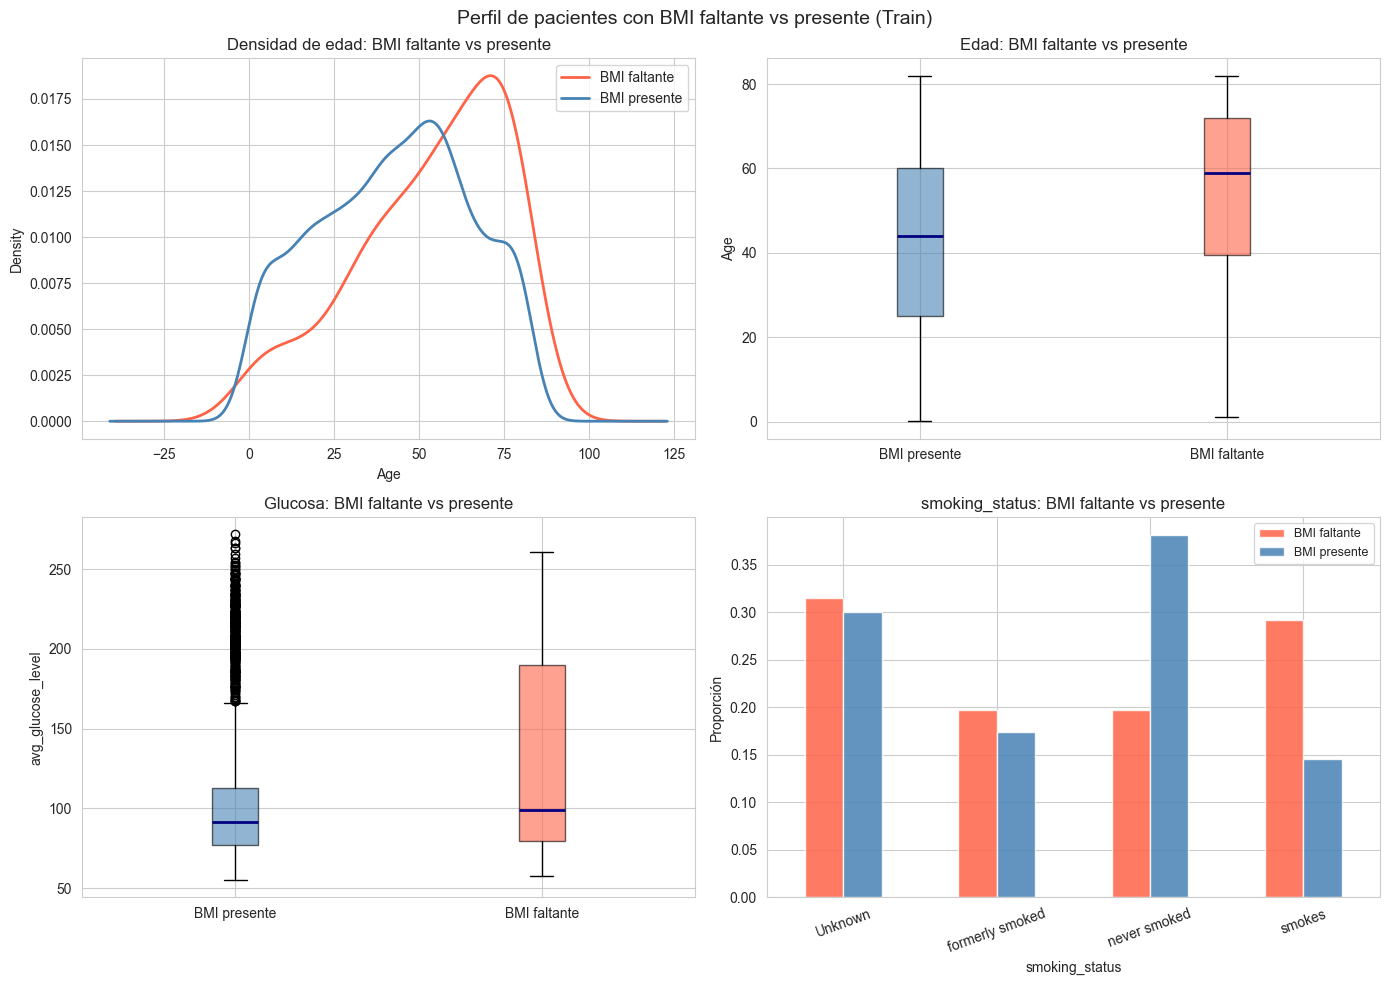

Edad media por grupo:
  BMI presente: 42.7 años
  BMI faltante: 53.5 años


In [168]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

bmi_missing_flag = df_train["bmi"].isnull()

# 1. Distribución de edad
df_train[bmi_missing_flag]["age"].plot(
    kind="kde", ax=axes[0, 0], label="BMI faltante", color="tomato", linewidth=2
)
df_train[~bmi_missing_flag]["age"].plot(
    kind="kde", ax=axes[0, 0], label="BMI presente", color="steelblue", linewidth=2
)
axes[0, 0].set_title("Densidad de edad: BMI faltante vs presente")
axes[0, 0].set_xlabel("Age")
axes[0, 0].legend()

# 2. Boxplot de edad
data_age = [df_train[~bmi_missing_flag]["age"], df_train[bmi_missing_flag]["age"]]
bp = axes[0, 1].boxplot(
    data_age,
    labels=["BMI presente", "BMI faltante"],
    patch_artist=True,
    medianprops=dict(color="navy", linewidth=2)
)
bp["boxes"][0].set_facecolor("steelblue")
bp["boxes"][0].set_alpha(0.6)
bp["boxes"][1].set_facecolor("tomato")
bp["boxes"][1].set_alpha(0.6)
axes[0, 1].set_title("Edad: BMI faltante vs presente")
axes[0, 1].set_ylabel("Age")

# 3. Boxplot glucosa
data_gluc = [
    df_train[~bmi_missing_flag]["avg_glucose_level"],
    df_train[bmi_missing_flag]["avg_glucose_level"]
]
bp2 = axes[1, 0].boxplot(
    data_gluc,
    labels=["BMI presente", "BMI faltante"],
    patch_artist=True,
    medianprops=dict(color="navy", linewidth=2)
)
bp2["boxes"][0].set_facecolor("steelblue")
bp2["boxes"][0].set_alpha(0.6)
bp2["boxes"][1].set_facecolor("tomato")
bp2["boxes"][1].set_alpha(0.6)
axes[1, 0].set_title("Glucosa: BMI faltante vs presente")
axes[1, 0].set_ylabel("avg_glucose_level")

# 4. smoking_status
missing_cats = df_train[bmi_missing_flag]["smoking_status"].value_counts(normalize=True)
present_cats = df_train[~bmi_missing_flag]["smoking_status"].value_counts(normalize=True)
compare = pd.DataFrame({
    "BMI faltante": missing_cats,
    "BMI presente": present_cats
})
compare.plot(
    kind="bar",
    ax=axes[1, 1],
    color=["tomato", "steelblue"],
    edgecolor="white",
    alpha=0.85
)
axes[1, 1].set_title("smoking_status: BMI faltante vs presente")
axes[1, 1].set_ylabel("Proporción")
axes[1, 1].tick_params(axis="x", rotation=20)
axes[1, 1].legend(fontsize=9)

plt.suptitle("Perfil de pacientes con BMI faltante vs presente (Train)", fontsize=14)
plt.tight_layout()
plt.show()

print("Edad media por grupo:")
print(f"  BMI presente: {df_train[~bmi_missing_flag]['age'].mean():.1f} años")
print(f"  BMI faltante: {df_train[bmi_missing_flag]['age'].mean():.1f} años")

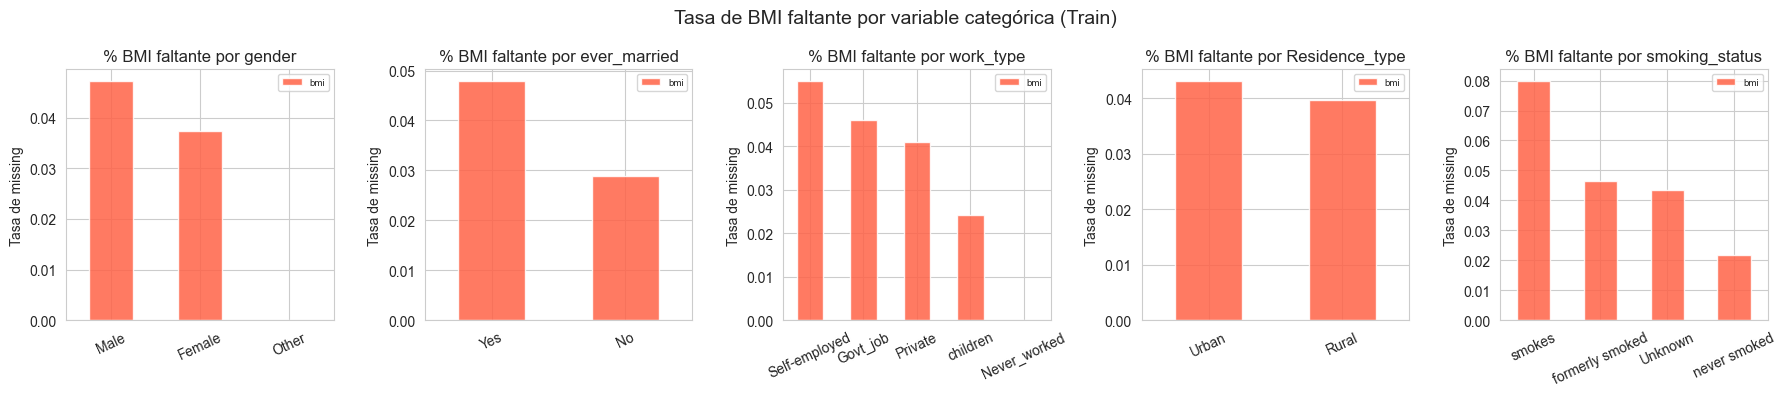

In [169]:
bmi_missing_flag = df_train["bmi"].isnull().astype(int)
cat_check = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

fig, axes = plt.subplots(1, len(cat_check), figsize=(18, 4))

for i, col in enumerate(cat_check):
    rate = bmi_missing_flag.groupby(X_train[col]).mean().sort_values(ascending=False)
    rate.plot(
        kind="bar",
        ax=axes[i],
        color="tomato",
        edgecolor="white",
        alpha=0.85
    )
    axes[i].set_title(f"% BMI faltante por {col}")
    axes[i].set_ylabel("Tasa de missing")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=25)
    axes[i].legend(fontsize=7)

plt.suptitle("Tasa de BMI faltante por variable categórica (Train)", fontsize=14)
plt.tight_layout()
plt.show()

#### Relación entre BMI y edad

Dado que la edad parece estar asociada tanto a la presencia de nulos como al valor del BMI, se analiza la relación entre ambas variables utilizando únicamente los registros con BMI observado.  
Esto servirá como base para definir una imputación guiada por rangos etarios.

C:\Users\pc\AppData\Local\Temp\ipykernel_22128\2025830951.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_by_age = train_complete.groupby("age_group_temp")["bmi"].agg(["median", "mean", "count"])


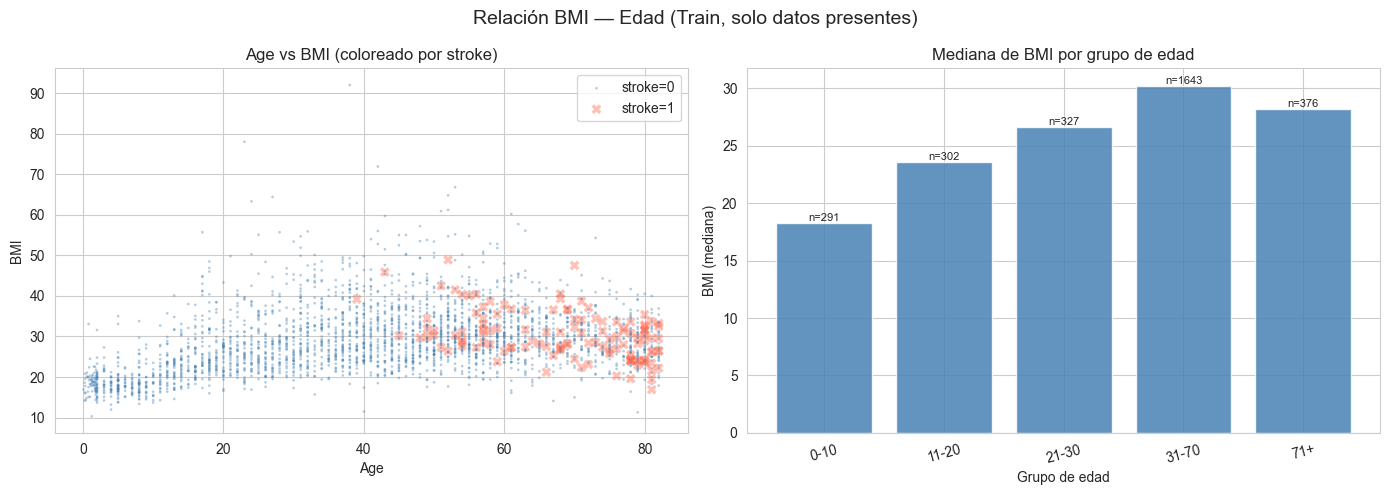

Mediana de BMI por grupo de edad:


,median,mean,count
age_group_temp,,,
0-10,18.3,18.75,291
11-20,23.6,25.14,302
21-30,26.6,28.34,327
31-70,30.2,31.46,1643
71+,28.2,28.66,376


In [170]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_complete = df_train[df_train["bmi"].notna()].copy()
y_complete = y_train[df_train["bmi"].notna()]

# 1. Scatter age vs BMI
for label, color, marker in zip([0, 1], ["steelblue", "tomato"], [".", "X"]):
    subset = train_complete[y_complete == label]
    axes[0].scatter(
        subset["age"],
        subset["bmi"],
        c=color,
        label=f"stroke={label}",
        alpha=0.4,
        s=15 if label == 0 else 50,
        marker=marker,
        edgecolors="none"
    )

axes[0].set_xlabel("Age")
axes[0].set_ylabel("BMI")
axes[0].set_title("Age vs BMI (coloreado por stroke)")
axes[0].legend()

# 2. Mediana de BMI por grupo de edad
age_bins = [0, 10, 20, 30, 70, np.inf]
age_labels = ["0-10", "11-20", "21-30", "31-70", "71+"]
train_complete["age_group_temp"] = pd.cut(
    train_complete["age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

bmi_by_age = train_complete.groupby("age_group_temp")["bmi"].agg(["median", "mean", "count"])

bars = axes[1].bar(
    bmi_by_age.index.astype(str),
    bmi_by_age["median"],
    color="steelblue",
    edgecolor="white",
    alpha=0.85
)

for bar, count in zip(bars, bmi_by_age["count"]):
    axes[1].annotate(
        f"n={count}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=8
    )

axes[1].set_title("Mediana de BMI por grupo de edad")
axes[1].set_ylabel("BMI (mediana)")
axes[1].set_xlabel("Grupo de edad")
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("Relación BMI — Edad (Train, solo datos presentes)", fontsize=14)
plt.tight_layout()
plt.show()

print("Mediana de BMI por grupo de edad:")
display(bmi_by_age.round(2))

#### Justificación de los rangos etarios para imputación de BMI

Para definir una imputación más informada, se analiza la evolución de la mediana de BMI en intervalos etarios finos de 5 años.  
La idea es identificar regiones donde el comportamiento del BMI sea relativamente homogéneo y agruparlas en bins más amplios pero clínicamente razonables.

C:\Users\pc\AppData\Local\Temp\ipykernel_22128\3744094738.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_stats = train_bmi.groupby("age_fine")["bmi"].agg(


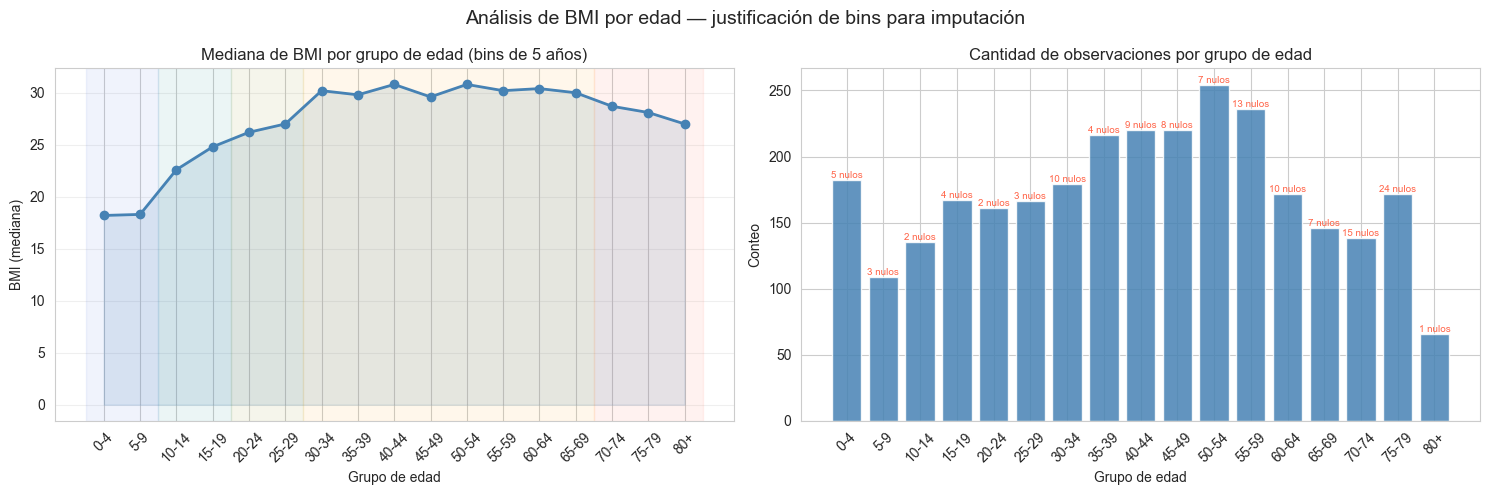

,mediana,media,conteo,nulos
age_fine,,,,
0-4,18.2,18.7,182,5
5-9,18.3,18.8,109,3
10-14,22.6,23.0,135,2
15-19,24.8,26.9,167,4
20-24,26.2,28.3,161,2
25-29,27.0,28.4,166,3
30-34,30.2,31.4,179,10
35-39,29.8,31.3,216,4
40-44,30.8,31.7,220,9


In [171]:
fine_bins = list(range(0, 85, 5)) + [np.inf]
fine_labels = [
    f"{b}-{fine_bins[i+1]-1}" if fine_bins[i+1] != np.inf else f"{b}+"
    for i, b in enumerate(fine_bins[:-1])
]

train_bmi = df_train.copy()
train_bmi["age_fine"] = pd.cut(
    train_bmi["age"],
    bins=fine_bins,
    labels=fine_labels,
    include_lowest=True
)

bmi_stats = train_bmi.groupby("age_fine")["bmi"].agg(
    mediana="median",
    media="mean",
    conteo="count",
    nulos=lambda x: x.isnull().sum()
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Mediana de BMI por bin
axes[0].plot(
    bmi_stats.index.astype(str),
    bmi_stats["mediana"],
    marker="o",
    color="steelblue",
    linewidth=2,
    markersize=6
)
axes[0].fill_between(
    range(len(bmi_stats)),
    bmi_stats["mediana"],
    alpha=0.15,
    color="steelblue"
)
axes[0].set_title("Mediana de BMI por grupo de edad (bins de 5 años)")
axes[0].set_ylabel("BMI (mediana)")
axes[0].set_xlabel("Grupo de edad")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.3)

for xmin, xmax, color in [
    (0, 2, "royalblue"),
    (2, 4, "teal"),
    (4, 6, "olive"),
    (6, 14, "orange"),
    (14, len(bmi_stats), "tomato")
]:
    axes[0].axvspan(
        xmin - 0.5,
        min(xmax - 0.5, len(bmi_stats) - 0.5),
        alpha=0.08,
        color=color
    )

# Conteo por bin
bars = axes[1].bar(
    bmi_stats.index.astype(str),
    bmi_stats["conteo"],
    color="steelblue",
    edgecolor="white",
    alpha=0.85
)
axes[1].set_title("Cantidad de observaciones por grupo de edad")
axes[1].set_ylabel("Conteo")
axes[1].set_xlabel("Grupo de edad")
axes[1].tick_params(axis="x", rotation=45)

for bar, nulos in zip(bars, bmi_stats["nulos"]):
    if nulos > 0:
        axes[1].annotate(
            f"{int(nulos)} nulos",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha="center",
            va="bottom",
            fontsize=7,
            color="tomato"
        )

plt.suptitle("Análisis de BMI por edad — justificación de bins para imputación", fontsize=14)
plt.tight_layout()
plt.show()

display(bmi_stats)

### Observaciones

- En edades tempranas, el BMI presenta valores claramente menores.
- Entre adolescencia y adultez temprana se observa una transición progresiva.
- Entre aproximadamente 30 y 70 años se aprecia una meseta relativamente estable.
- En edades avanzadas se observa una leve disminución del BMI.

A partir de este patrón, se proponen los siguientes rangos etarios para imputación:

**[0-10, 11-20, 21-30, 31-70, 71+]**

In [172]:
def compute_bmi_medians_by_age_group(df, age_col="age", bmi_col="bmi"):
    """Calcula las medianas de BMI por grupo de edad usando SOLO train.
    Devuelve (medianas_por_grupo_dict, mediana_global, age_bins, age_labels)."""
    df = df.copy()
    df[bmi_col] = pd.to_numeric(df[bmi_col], errors="coerce")

    age_bins = [0, 10, 20, 30, 70, np.inf]
    age_labels = ['0-10', '11-20', '21-30', '31-70', '71+']

    df['age_group_bmi_imp'] = pd.cut(
        df[age_col],
        bins=age_bins,
        labels=age_labels,
        include_lowest=True
    )

    medians_series = df.groupby('age_group_bmi_imp', observed=False)[bmi_col].median()
    medians_by_group = {str(k): float(v) for k, v in medians_series.items()}
    global_median = float(df[bmi_col].median())

    return medians_by_group, global_median, age_bins, age_labels


def apply_bmi_imputation(df, medians_by_group, global_median, age_bins, age_labels,
                        age_col="age", bmi_col="bmi"):
    """Aplica la imputación de BMI usando medianas pre-calculadas desde train (sin leakage)."""
    df = df.copy()
    df[bmi_col] = pd.to_numeric(df[bmi_col], errors="coerce")

    df['age_group_bmi_imp'] = pd.cut(
        df[age_col],
        bins=age_bins,
        labels=age_labels,
        include_lowest=True
    )

    # Mapear cada fila a la mediana de su grupo (calculada en train)
    # Casteamos a str para evitar dtype Categorical en el map
    mapped_medians = (
        df['age_group_bmi_imp'].astype(str).map(medians_by_group).astype(float)
    )

    # Imputar: primero con la mediana de grupo, luego fallback a mediana global
    fill_values = mapped_medians.fillna(global_median)
    df[bmi_col] = df[bmi_col].fillna(fill_values)

    return df


# Guardar BMI original (antes de imputar)
bmi_original = df_train["bmi"].copy()

# Fit SOLO en train: calcular medianas por grupo
bmi_medians, bmi_global_median, age_bins, age_labels = compute_bmi_medians_by_age_group(df_train)

# Aplicar imputación en df_train, X_val y X_test con las medianas de train
df_train = apply_bmi_imputation(df_train, bmi_medians, bmi_global_median, age_bins, age_labels)
X_val    = apply_bmi_imputation(X_val,    bmi_medians, bmi_global_median, age_bins, age_labels)
X_test   = apply_bmi_imputation(X_test,   bmi_medians, bmi_global_median, age_bins, age_labels)

# Verificación
display(df_train[["age", "age_group_bmi_imp", "bmi"]].head(10))

,age,age_group_bmi_imp,bmi
3135,44.0,31-70,30.2
3455,75.0,71+,27.8
1438,47.0,31-70,31.4
1566,76.0,71+,29.1
4182,28.0,21-30,21.5
257,32.0,31-70,32.3
4261,25.0,21-30,23.5
3378,51.0,31-70,29.8
4191,31.0,31-70,28.3
5084,67.0,31-70,26.9


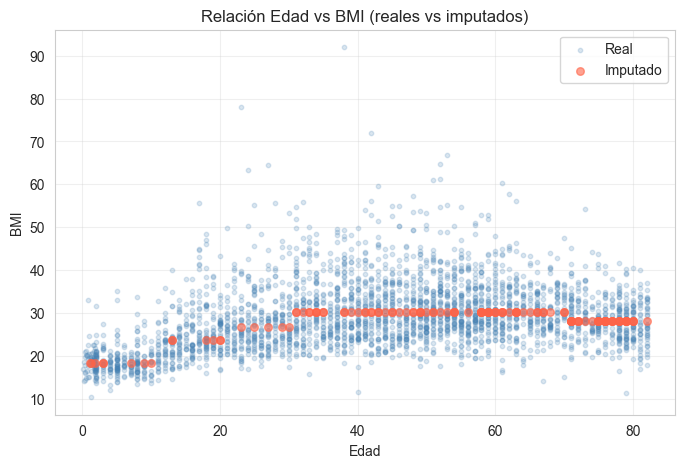

In [173]:
# máscara de imputados
mask_imputed = bmi_original.isna()

plt.figure(figsize=(8,5))

# Datos reales
plt.scatter(
    df_train.loc[~mask_imputed, "age"],
    df_train.loc[~mask_imputed, "bmi"],
    alpha=0.2,
    s=10,
    color="steelblue",
    label="Real"
)

# Datos imputados
plt.scatter(
    df_train.loc[mask_imputed, "age"],
    df_train.loc[mask_imputed, "bmi"],
    alpha=0.6,
    s=30,
    color="tomato",
    label="Imputado"
)

plt.title("Relación Edad vs BMI (reales vs imputados)")
plt.xlabel("Edad")
plt.ylabel("BMI")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

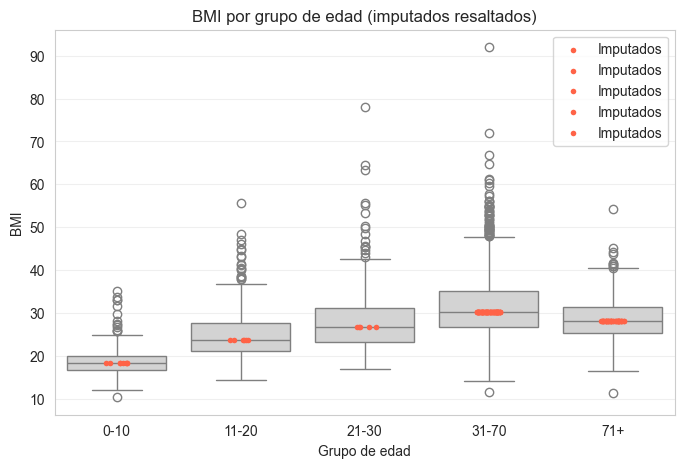

In [174]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_train,
    x="age_group_bmi_imp",
    y="bmi",
    color="lightgray"
)

sns.stripplot(
    data=df_train[mask_imputed],
    x="age_group_bmi_imp",
    y="bmi",
    color="tomato",
    size=4,
    label="Imputados"
)

plt.title("BMI por grupo de edad (imputados resaltados)")
plt.xlabel("Grupo de edad")
plt.ylabel("BMI")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

#### Validación de la imputación en función de la edad

Dado que la imputación de BMI se realizó en función de rangos etarios, se analiza la relación entre edad y BMI, diferenciando entre valores observados e imputados.

Se observa que los valores imputados se alinean con la distribución de los datos reales dentro de cada grupo de edad, sin generar patrones artificiales ni valores fuera de rango.

Esto confirma que la imputación respeta la relación existente entre edad y BMI, manteniendo la coherencia estructural del dataset.

### Transformación logarítmica de las variables avg_glucose_level y bmi

Para lograr un mejor aprovechamiento de la información de estas variables, se aplica una transformación logarítmica sobre los datos.

In [175]:
df_train["log_bmi"] = np.log(df_train["bmi"])
X_val["log_bmi"] = np.log(X_val["bmi"])
X_test["log_bmi"] = np.log(X_test["bmi"])

df_train["log_glucose"] = np.log(df_train["avg_glucose_level"])
X_val["log_glucose"] = np.log(X_val["avg_glucose_level"])
X_test["log_glucose"] = np.log(X_test["avg_glucose_level"])

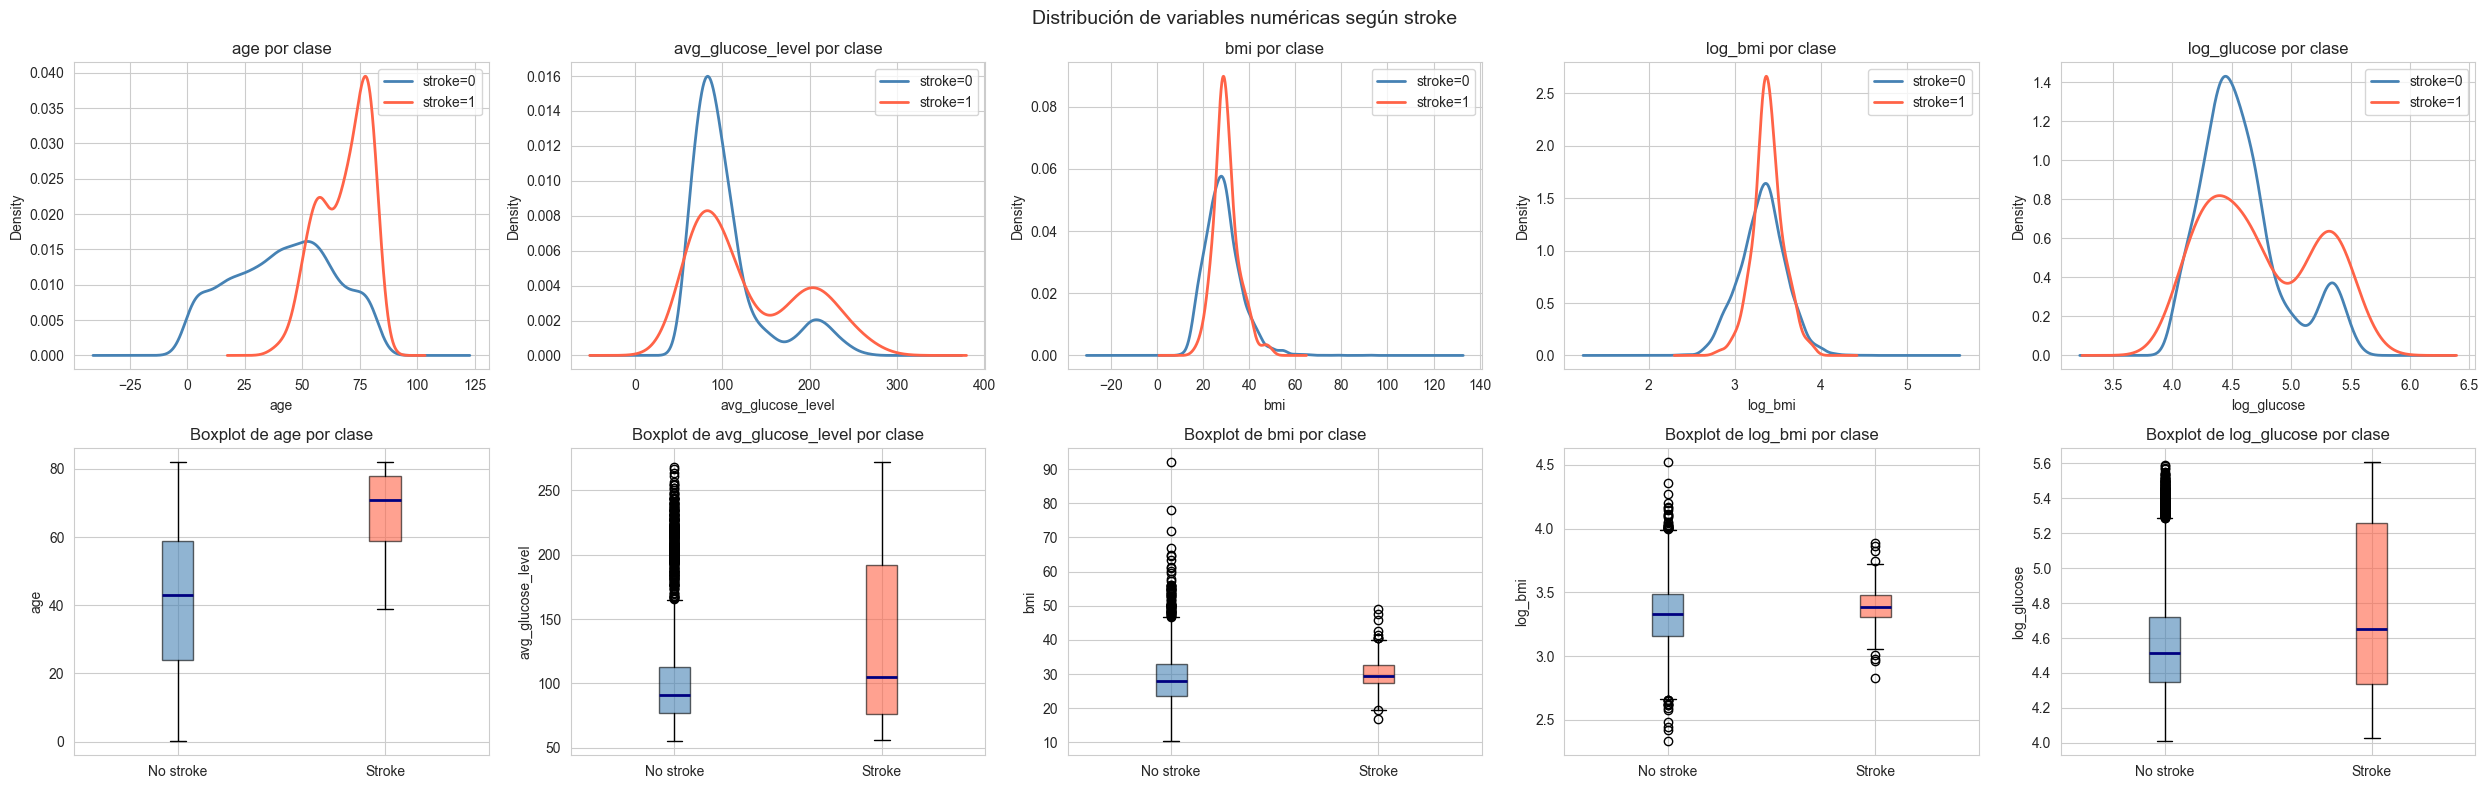

In [176]:
# ===============================
# VARIABLES NUMÉRICAS VS TARGET
# ===============================
num_cols = ["age", "avg_glucose_level", "bmi", "log_bmi", "log_glucose"]
fig, axes = plt.subplots(2, len(num_cols), figsize=(5 * len(num_cols), 8))

for i, col in enumerate(num_cols):
    
    # KDE por clase
    for label, color in zip([0, 1], ["steelblue", "tomato"]):
        subset = df_train[df_train["stroke"] == label][col].dropna()
        subset.plot(
            kind="kde",
            ax=axes[0, i],
            label=f"stroke={label}",
            color=color,
            linewidth=2
        )
    
    axes[0, i].set_title(f"{col} por clase")
    axes[0, i].set_xlabel(col)
    axes[0, i].legend()

    # Boxplot por clase
    data_by_class = [
        df_train[df_train["stroke"] == lbl][col].dropna()
        for lbl in [0, 1]
    ]

    bp = axes[1, i].boxplot(
        data_by_class,
        labels=["No stroke", "Stroke"],
        patch_artist=True,
        medianprops=dict(color="navy", linewidth=2)
    )

    bp["boxes"][0].set_facecolor("steelblue")
    bp["boxes"][0].set_alpha(0.6)
    bp["boxes"][1].set_facecolor("tomato")
    bp["boxes"][1].set_alpha(0.6)

    axes[1, i].set_title(f"Boxplot de {col} por clase")
    axes[1, i].set_ylabel(col)

plt.suptitle("Distribución de variables numéricas según stroke", fontsize=14)
plt.tight_layout()
plt.show()

In [177]:
log_cols = ["log_bmi", "log_glucose"]
df_train.drop(columns=log_cols, inplace=True)
X_val.drop(columns=log_cols, inplace=True)
X_test.drop(columns=log_cols, inplace=True)

display(df_train.columns)

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke', 'age_group_bmi_imp'],
      dtype='object')

## 4. Análisis de `smoking_status = "Unknown"`

Esta sección explora si `"Unknown"` se comporta como una categoría propia o podría agruparse con otra categoría de tabaquismo.


In [178]:
# --- Proporción y conteo de Unknown en train ---
smoking_counts = df_train["smoking_status"].value_counts()
smoking_pct = df_train["smoking_status"].value_counts(normalize=True)

summary_smoking = pd.DataFrame({"conteo": smoking_counts, "proporción": smoking_pct.round(4)})
display(summary_smoking)

n_unknown = (df_train["smoking_status"] == "Unknown").sum()
print(f"\n'Unknown' representa {n_unknown} filas ({n_unknown/len(df_train):.1%} del train set)")
print(f"No es un nulo técnico (no aparece en isnull), sino un valor explícito del dataset.")

,conteo,proporción
smoking_status,,
never smoked,1144,0.3731
Unknown,921,0.3004
formerly smoked,537,0.1751
smokes,464,0.1513



'Unknown' representa 921 filas (30.0% del train set)
No es un nulo técnico (no aparece en isnull), sino un valor explícito del dataset.


C:\Users\pc\AppData\Local\Temp\ipykernel_22128\3055913878.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x="smoking_status", y="age", ax=axes[0, 0],


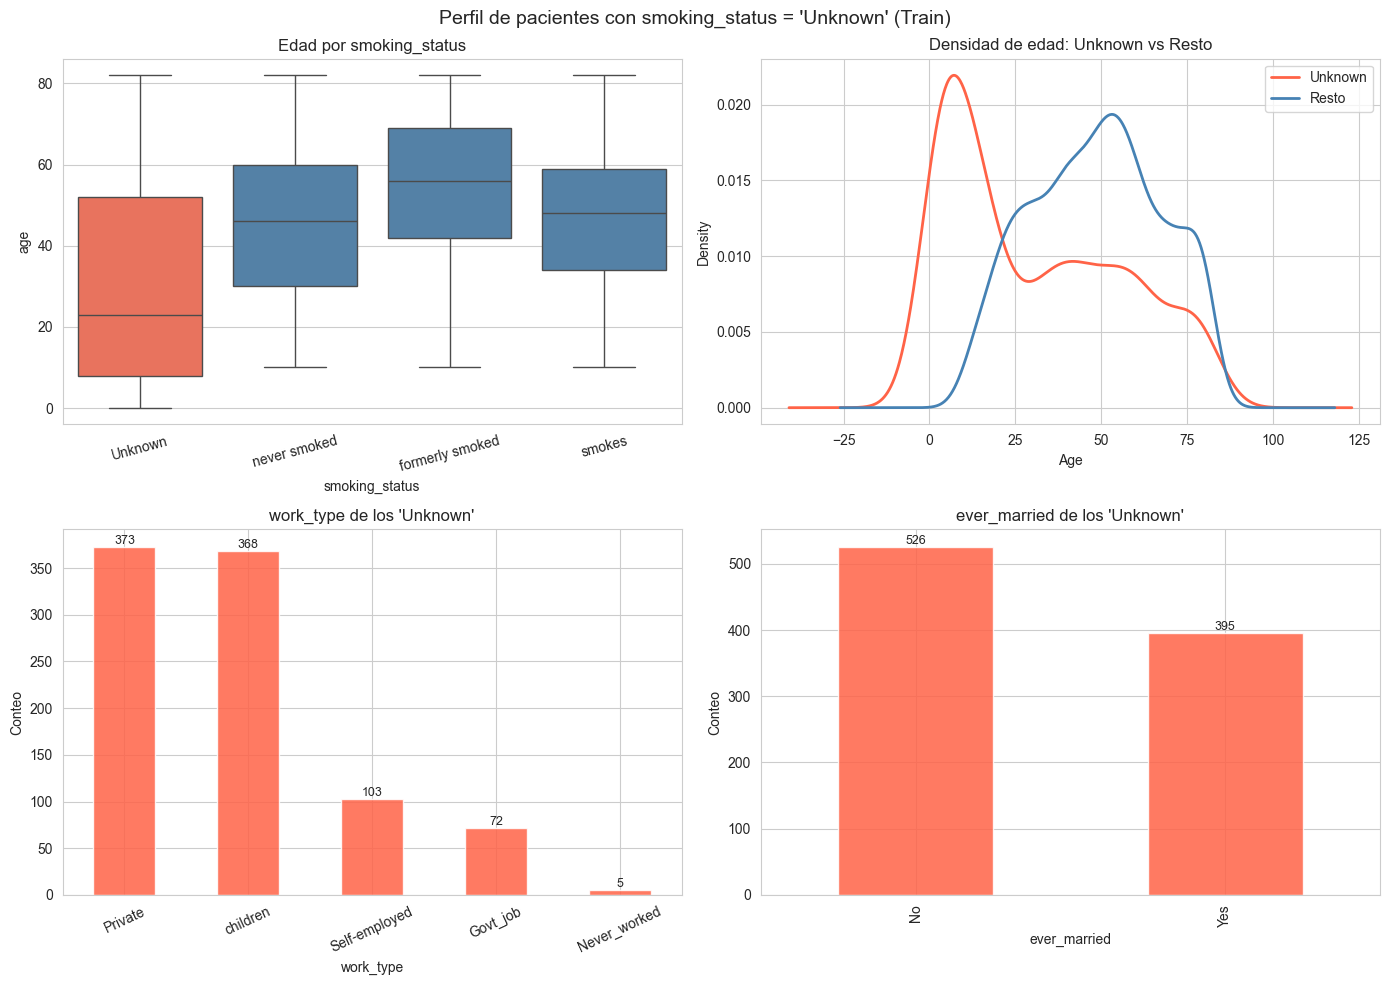

Edad media por smoking_status:
                 mean  median   min   max
smoking_status                           
Unknown          30.5    23.0   0.1  82.0
formerly smoked  54.5    56.0  10.0  82.0
never smoked     46.0    46.0  10.0  82.0
smokes           47.8    48.0  10.0  82.0

% de menores de 18 años dentro de Unknown: 44.1%


In [179]:
# --- Perfil demográfico de Unknown vs otras categorías ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución de edad por smoking_status
sns.boxplot(data=df_train, x="smoking_status", y="age", ax=axes[0, 0],
            order=["Unknown", "never smoked", "formerly smoked", "smokes"],
            palette={"Unknown": "tomato", "never smoked": "steelblue",
                     "formerly smoked": "steelblue", "smokes": "steelblue"})
axes[0, 0].set_title("Edad por smoking_status")
axes[0, 0].tick_params(axis="x", rotation=15)

# 2. Distribución de edad: KDE Unknown vs resto
df_train[df_train["smoking_status"] == "Unknown"]["age"].plot(
    kind="kde", ax=axes[0, 1], label="Unknown", color="tomato", linewidth=2)
df_train[df_train["smoking_status"] != "Unknown"]["age"].plot(
    kind="kde", ax=axes[0, 1], label="Resto", color="steelblue", linewidth=2)
axes[0, 1].set_title("Densidad de edad: Unknown vs Resto")
axes[0, 1].set_xlabel("Age")
axes[0, 1].legend()

# 3. Work type dentro de Unknown
unknown_work = df_train[df_train["smoking_status"] == "Unknown"]["work_type"].value_counts()
unknown_work.plot(kind="bar", ax=axes[1, 0], color="tomato", edgecolor="white", alpha=0.85)
axes[1, 0].set_title("work_type de los 'Unknown'")
axes[1, 0].set_ylabel("Conteo")
axes[1, 0].tick_params(axis="x", rotation=25)
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{int(p.get_height())}",
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha="center", va="bottom", fontsize=9)

# 4. ever_married dentro de Unknown
unknown_married = df_train[df_train["smoking_status"] == "Unknown"]["ever_married"].value_counts()
unknown_married.plot(kind="bar", ax=axes[1, 1], color="tomato", edgecolor="white", alpha=0.85)
axes[1, 1].set_title("ever_married de los 'Unknown'")
axes[1, 1].set_ylabel("Conteo")
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{int(p.get_height())}",
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha="center", va="bottom", fontsize=9)

plt.suptitle("Perfil de pacientes con smoking_status = 'Unknown' (Train)", fontsize=14)
plt.tight_layout()
plt.show()

# Estadísticas numéricas
print("Edad media por smoking_status:")
print(df_train.groupby("smoking_status")["age"].agg(["mean", "median", "min", "max"]).round(1))
print(f"\n% de menores de 18 años dentro de Unknown: "
      f"{(df_train[df_train['smoking_status']=='Unknown']['age'] < 18).mean():.1%}")

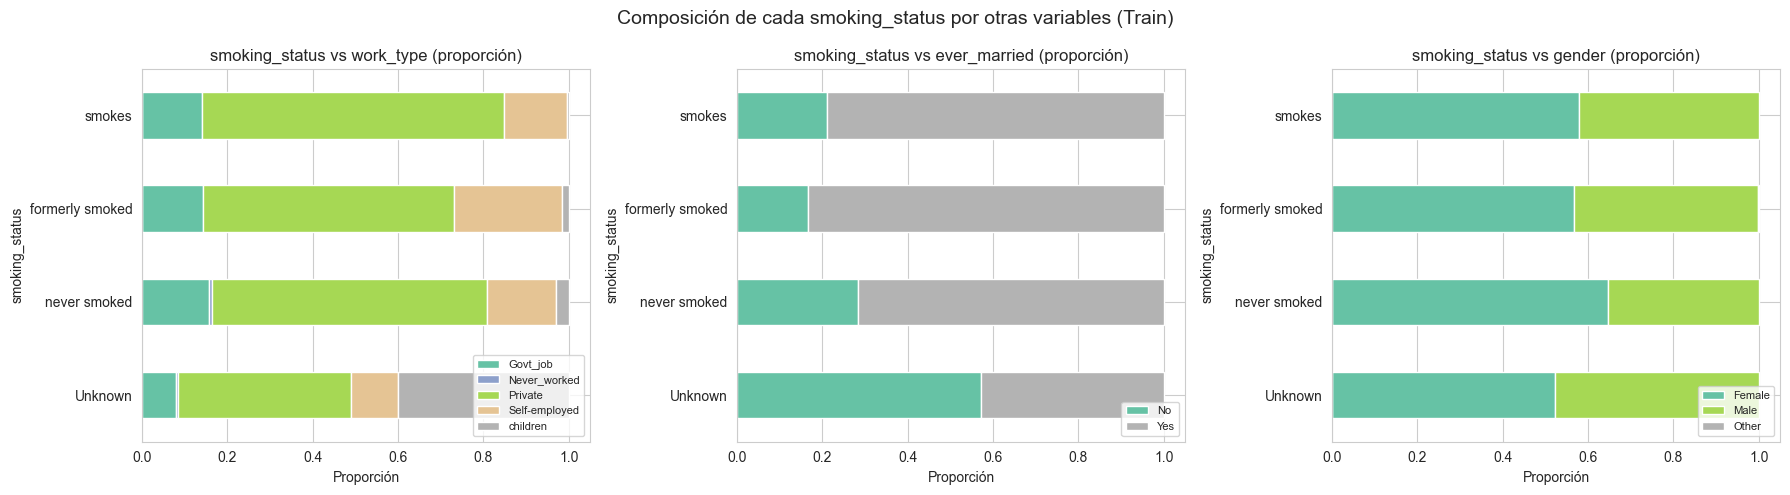

In [180]:
# --- Crosstab: smoking_status vs otras categóricas ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ["work_type", "ever_married", "gender"]):
    ct = pd.crosstab(df_train["smoking_status"], df_train[col], normalize="index")
    ct.loc[["Unknown", "never smoked", "formerly smoked", "smokes"]].plot(
        kind="barh", stacked=True, ax=ax, colormap="Set2", edgecolor="white")
    ax.set_title(f"smoking_status vs {col} (proporción)")
    ax.set_xlabel("Proporción")
    ax.legend(fontsize=8, loc="lower right")

plt.suptitle("Composición de cada smoking_status por otras variables (Train)", fontsize=14)
plt.tight_layout()
plt.show()

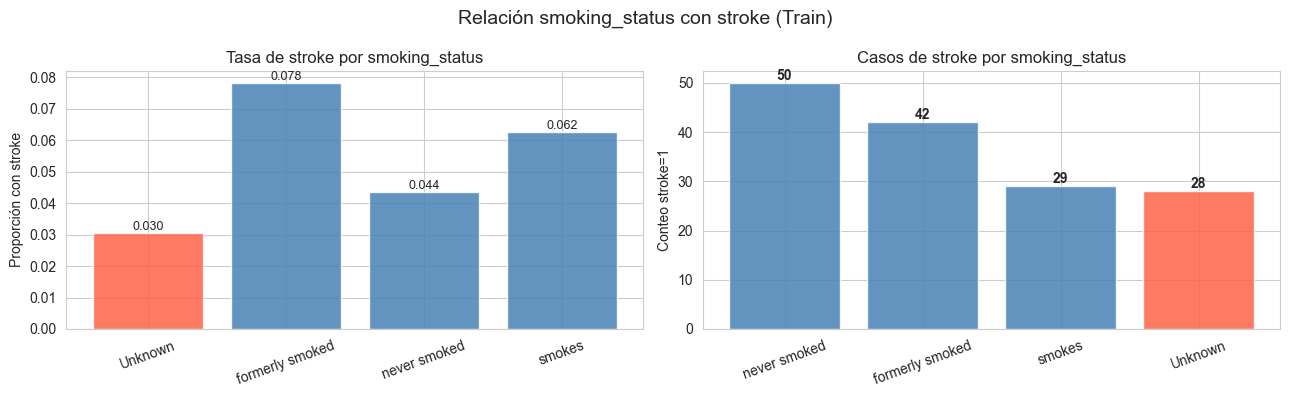

Tasa de stroke y conteo por categoría:


,n_stroke,n_total,tasa_stroke
smoking_status,,,
formerly smoked,42,537,0.078212
smokes,29,464,0.062500
never smoked,50,1144,0.043706
Unknown,28,921,0.030402


In [181]:
# --- Tasa de stroke: Unknown vs otras categorías ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Calcular métricas sin usar mean
stroke_stats = (
    y_train.groupby(df_train["smoking_status"])
    .agg(n_stroke="sum", n_total="count")
)

stroke_stats["tasa_stroke"] = stroke_stats["n_stroke"] / stroke_stats["n_total"]

# Colores (destacar Unknown)
colors = ["tomato" if idx == "Unknown" else "steelblue" for idx in stroke_stats.index]

# 1. Tasa de stroke
axes[0].bar(
    stroke_stats.index,
    stroke_stats["tasa_stroke"],
    color=colors,
    edgecolor="white",
    alpha=0.85
)

axes[0].set_title("Tasa de stroke por smoking_status")
axes[0].set_ylabel("Proporción con stroke")
axes[0].tick_params(axis="x", rotation=20)

# Agregar valores arriba de las barras
for p in axes[0].patches:
    axes[0].annotate(
        f"{p.get_height():.3f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9
    )

# 2. Conteo de stroke=1
stroke_counts = df_train[y_train == 1]["smoking_status"].value_counts()

colors2 = ["tomato" if idx == "Unknown" else "steelblue" for idx in stroke_counts.index]

axes[1].bar(
    stroke_counts.index,
    stroke_counts.values,
    color=colors2,
    edgecolor="white",
    alpha=0.85
)

axes[1].set_title("Casos de stroke por smoking_status")
axes[1].set_ylabel("Conteo stroke=1")
axes[1].tick_params(axis="x", rotation=20)

# Labels en barras
for p in axes[1].patches:
    axes[1].annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.suptitle("Relación smoking_status con stroke (Train)", fontsize=14)
plt.tight_layout()
plt.show()

# Tabla resumen
print("Tasa de stroke y conteo por categoría:")

display(
    stroke_stats
    .rename(columns={
        "tasa_stroke": "tasa_stroke",
        "n_stroke": "n_stroke",
        "n_total": "n_total"
    })
    .sort_values("tasa_stroke", ascending=False)
)

stroke,No stroke,Stroke
smoking_status,,
Unknown,0.9696,0.0304
formerly smoked,0.9218,0.0782
never smoked,0.9563,0.0437
smokes,0.9375,0.0625


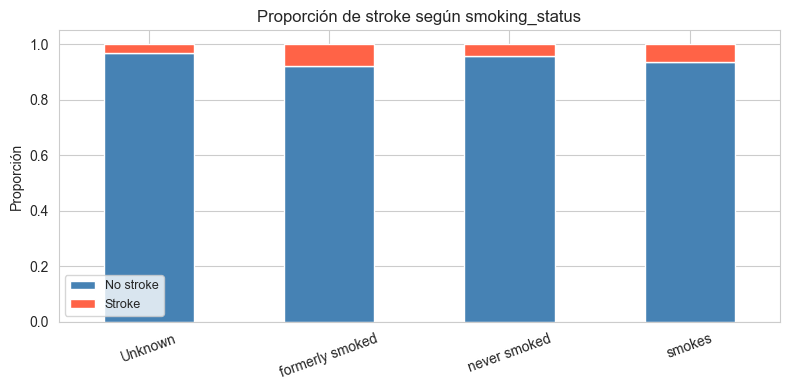

In [182]:
# --- Proporción de stroke según smoking_status ---

ctab = pd.crosstab(
    X_train["smoking_status"],
    y_train,
    normalize="index"
)

ctab = ctab.rename(columns={0: "No stroke", 1: "Stroke"})
display(ctab.round(4))
# --- Visualización: stroke según smoking_status ---

ctab.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 4),
    color=["steelblue", "tomato"],
    edgecolor="white"
)

plt.title("Proporción de stroke según smoking_status")
plt.ylabel("Proporción")
plt.xlabel("")
plt.xticks(rotation=20)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [183]:
# --- Resumen: ¿quiénes son los Unknown? ---
unknown = df_train[df_train["smoking_status"] == "Unknown"]
known = df_train[df_train["smoking_status"] != "Unknown"]
y_unknown = y_train[df_train["smoking_status"] == "Unknown"]
y_known = y_train[df_train["smoking_status"] != "Unknown"]

resumen = pd.DataFrame({
    "Unknown": [
        len(unknown),
        unknown["age"].mean(),
        unknown["age"].median(),
        (unknown["age"] < 18).mean(),
        (unknown["work_type"] == "children").mean(),
        (unknown["ever_married"] == "No").mean(),
        y_unknown.mean(),
    ],
    "Resto": [
        len(known),
        known["age"].mean(),
        known["age"].median(),
        (known["age"] < 18).mean(),
        (known["work_type"] == "children").mean(),
        (known["ever_married"] == "No").mean(),
        y_known.mean(),
    ]
}, index=["N", "Edad media", "Edad mediana", "% menores 18",
          "% work_type=children", "% ever_married=No", "Tasa de stroke"])

display(resumen.round(4))


,Unknown,Resto
N,921.0000,2145.0000
Edad media,30.5387,48.5329
Edad mediana,23.0000,49.0000
% menores 18,0.4408,0.0443
% work_type=children,0.3996,0.0205
% ever_married=No,0.5711,0.2387
Tasa de stroke,0.0304,0.0564


#### Conclusión del análisis de `Unknown`

Del análisis exploratorio se observa que la categoría `Unknown` no parece estar distribuida de manera completamente aleatoria. En particular, se asocia con una estructura etaria diferente respecto de las categorías con información disponible, concentrándose en mayor medida en individuos más jóvenes.

En consecuencia, se decide reemplazar "Unknown" por "never smoked"

### Decisión de preprocesamiento para `smoking_status`

Se reemplaza `"Unknown"` por `"never smoked"` en ambos sets (train y test).


In [184]:
# Smoking_status replacement
df_train["smoking_status"] = df_train["smoking_status"].replace("Unknown", "never smoked")
X_val["smoking_status"]    = X_val["smoking_status"].replace("Unknown", "never smoked")
X_test["smoking_status"]   = X_test["smoking_status"].replace("Unknown", "never smoked")

## 7. Encoding y construcción de las matrices procesadas


In [185]:
# Eliminar filas con gender="Other" (muy pocas observaciones en todo el dataset)
mask_train = df_train["gender"] != "Other"
df_train = df_train[mask_train]
y_train = y_train[mask_train]

mask_val = X_val["gender"] != "Other"
X_val = X_val[mask_val]
y_val = y_val[mask_val]

mask_test = X_test["gender"] != "Other"
X_test = X_test[mask_test]
y_test = y_test[mask_test]

print(f"Train: {df_train.shape[0]} filas | Val: {X_val.shape[0]} filas | Test: {X_test.shape[0]} filas")

Train: 3065 filas | Val: 1022 filas | Test: 1022 filas


In [186]:
# Gender encoding
gender_map = {"Male": 0, "Female": 1}
df_train["gender"] = df_train["gender"].map(gender_map)
X_val["gender"]    = X_val["gender"].map(gender_map)
X_test["gender"]   = X_test["gender"].map(gender_map)

# Ever married encoding
ever_married_map = {"Yes": 1, "No": 0}
df_train["ever_married"] = df_train["ever_married"].map(ever_married_map)
X_val["ever_married"]    = X_val["ever_married"].map(ever_married_map)
X_test["ever_married"]   = X_test["ever_married"].map(ever_married_map)

# Residence type encoding
residence_map = {"Urban": 1, "Rural": 0}
df_train["Residence_type"] = df_train["Residence_type"].map(residence_map)
X_val["Residence_type"]    = X_val["Residence_type"].map(residence_map)
X_test["Residence_type"]   = X_test["Residence_type"].map(residence_map)

In [187]:
# Verificar categorías de work_type
print("work_type categories:")
print(df_train["work_type"].value_counts())



work_type categories:
work_type
Private          1757
Self-employed     492
children          412
Govt_job          392
Never_worked       12
Name: count, dtype: int64


In [188]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = [
    "work_type",
    "smoking_status",
]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=int, drop='first')

# Fit only on train
df_train_encoded = encoder.fit_transform(df_train[cat_cols])

# Transform val y test
X_val_encoded  = encoder.transform(X_val[cat_cols])
X_test_encoded = encoder.transform(X_test[cat_cols])

In [189]:
encoded_cols = encoder.get_feature_names_out(cat_cols)

df_train_encoded = pd.DataFrame(
    df_train_encoded,
    columns=encoded_cols,
    index=df_train.index
)

X_val_encoded = pd.DataFrame(
    X_val_encoded,
    columns=encoded_cols,
    index=X_val.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_cols,
    index=X_test.index
)

display(df_train_encoded.head())

,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_never smoked,smoking_status_smokes
3135,0,1,0,0,1,0
3455,0,0,0,0,1,0
1438,0,1,0,0,1,0
1566,0,0,1,0,1,0
4182,0,1,0,0,1,0


In [190]:
# Columnas
num_cols_model = ["age", "avg_glucose_level", "bmi"]
bin_cols = ["hypertension", "heart_disease", "gender", "ever_married", "Residence_type"]

# -------------------------
# TRAIN
# -------------------------
df_train_final = pd.concat(
    [
        df_train[num_cols_model + bin_cols + ["stroke"]],
        df_train_encoded
    ],
    axis=1
)

# -------------------------
# VALIDACIÓN
# -------------------------
X_val_final = pd.concat(
    [
        X_val[num_cols_model + bin_cols],
        X_val_encoded
    ],
    axis=1
)

# -------------------------
# TEST
# -------------------------
X_test_final = pd.concat(
    [
        X_test[num_cols_model + bin_cols],
        X_test_encoded
    ],
    axis=1
)

# -------------------------
# Prints
# -------------------------
print("df_train_final shape:", df_train_final.shape)
print("X_val_final shape:",    X_val_final.shape)
print("X_test_final shape:",   X_test_final.shape)

display(df_train_final.head())


df_train_final shape: (3065, 15)
X_val_final shape: (1022, 14)
X_test_final shape: (1022, 14)


,age,avg_glucose_level,bmi,hypertension,heart_disease,gender,ever_married,Residence_type,stroke,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_never smoked,smoking_status_smokes
3135,44.0,84.10,30.2,1,0,0,1,0,0,0,1,0,0,1,0
3455,75.0,223.14,27.8,0,0,0,1,1,0,0,0,0,0,1,0
1438,47.0,93.55,31.4,0,0,0,1,0,0,0,1,0,0,1,0
1566,76.0,101.43,29.1,0,1,0,1,0,0,0,0,1,0,1,0
4182,28.0,104.16,21.5,0,0,1,0,0,0,0,1,0,0,1,0


In [191]:
print("Missing values in processed matrices:")
print("Train:", df_train_final.isnull().sum().sum())

Missing values in processed matrices:
Train: 0


In [192]:

X_train_final = df_train_final.drop(columns=["stroke"])
y_train_final = df_train_final["stroke"]

X_train_final.info

<bound method DataFrame.info of        age  avg_glucose_level   bmi  hypertension  heart_disease  gender  \
3135  44.0              84.10  30.2             1              0       0   
3455  75.0             223.14  27.8             0              0       0   
1438  47.0              93.55  31.4             0              0       0   
1566  76.0             101.43  29.1             0              1       0   
4182  28.0             104.16  21.5             0              0       1   
...    ...                ...   ...           ...            ...     ...   
2206  40.0             114.32  28.3             0              0       1   
1434  45.0              92.86  35.1             0              0       1   
461   16.0             113.47  19.5             0              0       1   
1052  61.0              78.65  36.2             0              0       1   
5052   6.0              91.05  22.1             0              0       1   

      ever_married  Residence_type  work_type_Never_wor

In [193]:
X_train_final.to_csv('../datasets/X_train.csv', index=False)
X_val_final.to_csv('../datasets/X_val.csv',   index=False)
X_test_final.to_csv('../datasets/X_test.csv', index=False)
y_train.to_csv('../datasets/y_train.csv', index=False)
y_val.to_csv('../datasets/y_val.csv',     index=False)
y_test.to_csv('../datasets/y_test.csv',   index=False)

In [194]:
X_train_final

,age,avg_glucose_level,bmi,hypertension,heart_disease,gender,ever_married,Residence_type,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_never smoked,smoking_status_smokes
3135,44.0,84.10,30.2,1,0,0,1,0,0,1,0,0,1,0
3455,75.0,223.14,27.8,0,0,0,1,1,0,0,0,0,1,0
1438,47.0,93.55,31.4,0,0,0,1,0,0,1,0,0,1,0
1566,76.0,101.43,29.1,0,1,0,1,0,0,0,1,0,1,0
4182,28.0,104.16,21.5,0,0,1,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2206,40.0,114.32,28.3,0,0,1,1,1,0,0,0,0,0,1
1434,45.0,92.86,35.1,0,0,1,1,1,0,1,0,0,0,0
461,16.0,113.47,19.5,0,0,1,0,0,0,0,0,1,1,0
1052,61.0,78.65,36.2,0,0,1,1,0,0,1,0,0,0,0


In [195]:
# ============================================================
# Baseline antes de escalar: age > threshold
# ============================================================

class AgeBaselineClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, threshold=50):
        self.threshold = threshold

    def fit(self, X, y=None):
        self.classes_ = np.array([0, 1])
        return self

    def predict(self, X):
        return (X["age"].values > self.threshold).astype(int)

    def predict_proba(self, X):
        y_pred = self.predict(X)
        return np.column_stack([1 - y_pred, y_pred])

# ============================================================
# Entrenar y evaluar baseline
# ============================================================

BETA = 2
METRIC_NAME = f"F{BETA}"

age_baseline = AgeBaselineClassifier(threshold=50)
age_baseline.fit(X_train_final, y_train)

y_pred_age = age_baseline.predict(X_val_final)
y_proba_age = age_baseline.predict_proba(X_val_final)[:, 1]

print(f"\nAge Baseline (age > 50):")
print(f"  {METRIC_NAME:<12} {fbeta_score(y_val, y_pred_age, beta=BETA):.4f}")
print(f"  {'Recall':<12} {recall_score(y_val, y_pred_age):.4f}")
print(f"  {'Precision':<12} {precision_score(y_val, y_pred_age, zero_division=0):.4f}")
print(f"  {'ROC-AUC':<12} {roc_auc_score(y_val, y_proba_age):.4f}")
print(f"  {'PR-AUC':<12} {average_precision_score(y_val, y_proba_age):.4f}")

joblib.dump(age_baseline, '../models/age_baseline.pkl')


Age Baseline (age > 50):
  F2           0.3231
  Recall       0.8000
  Precision    0.0955
  ROC-AUC      0.7050
  PR-AUC       0.0862


['../models/age_baseline.pkl']

## 8. Escalado para los modelos


In [196]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

num_cols = ["age", "avg_glucose_level", "bmi"]

preprocessor = ColumnTransformer(
    transformers=[("scaler", StandardScaler(), num_cols)],
    remainder="passthrough"
)

X_train_scaled = preprocessor.fit_transform(X_train_final)
X_val_scaled   = preprocessor.transform(X_val_final)
X_test_scaled  = preprocessor.transform(X_test_final)

print("Scaling completed.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_val_scaled shape:",   X_val_scaled.shape)
print("X_test_scaled shape:",  X_test_scaled.shape)

Scaling completed.
X_train_scaled shape: (3065, 14)
X_val_scaled shape: (1022, 14)
X_test_scaled shape: (1022, 14)


In [197]:

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_final.columns)
X_val_scaled_df   = pd.DataFrame(X_val_scaled,   columns=X_val_final.columns)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=X_test_final.columns)

print(X_train_scaled_df.head())

        age  avg_glucose_level       bmi  hypertension  heart_disease  gender  \
0  0.038722          -0.482734  0.177019           1.0            0.0     0.0   
1  1.423515           2.608955 -0.132442           0.0            0.0     0.0   
2  0.172734          -0.272604  0.331749           0.0            0.0     0.0   
3  1.468186          -0.097385  0.035182           0.0            1.0     0.0   
4 -0.676010          -0.036681 -0.944776           0.0            0.0     1.0   

   ever_married  Residence_type  work_type_Never_worked  work_type_Private  \
0           1.0             0.0                     0.0                1.0   
1           1.0             1.0                     0.0                0.0   
2           1.0             0.0                     0.0                1.0   
3           1.0             0.0                     0.0                0.0   
4           0.0             0.0                     0.0                1.0   

   work_type_Self-employed  work_type_childr

In [198]:
import joblib
import os
os.makedirs("../data", exist_ok=True)

# guardar datos procesados
joblib.dump({
    "X_train": X_train_scaled,
    "X_val":   X_val_scaled,
    "X_test":  X_test_scaled,
    "y_train": y_train,
    "y_val":   y_val,
    "y_test":  y_test,
    "feature_names": list(X_train_final.columns)
}, "../data/processed_data.pkl")

print("Datos exportados a data/processed_data.pkl")
print(f"X_train: {X_train_scaled.shape} | X_val: {X_val_scaled.shape} | X_test: {X_test_scaled.shape}")
print(f"Features: {list(X_train_final.columns)}")

Datos exportados a data/processed_data.pkl
X_train: (3065, 14) | X_val: (1022, 14) | X_test: (1022, 14)
Features: ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'gender', 'ever_married', 'Residence_type', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_never smoked', 'smoking_status_smokes']


In [199]:
X_val_final[X_val_final.isnull().any(axis=1)]

,age,avg_glucose_level,bmi,hypertension,heart_disease,gender,ever_married,Residence_type,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_never smoked,smoking_status_smokes


## Conclusión final

- age es la variable más correlacionada, seguida de las variables asociadas a condiciones médicas, como heart_disease y hypertension.
- El target se encuentra fuertemente desbalanceado, lo que va a influir fuertemente sobre el modelo a elegir y las métricas de evaluación a utilizar.
- Se logró evitar eliminación de faltantes utilizando imputación 
- Contamos con 3 variables numéricas, que se normalizaron. 
- El dataset posee 7 variables categóricas:  'gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'hypertension', 'heart_disease'. Estas se codificaron de forma binaria o utilizando OneHotEncoder